# A Framework for Early Bitcoin Bubble Detection

## Libraries upload

In [1]:
pip install lppls

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 328.3/328.3 kB 7.9 MB/s eta 0:00:00


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
#import time
import numpy as np
from sklearn.preprocessing import MinMaxScaler

## Full dataset upload

In [ ]:
df = pd.read_csv('df.csv')
print(df.head())

         Date        Close  fear_greed_index
0  2018-02-01  9170.540039              30.0
1  2018-02-02  8830.750000              15.0
2  2018-02-03  9174.910156              40.0
3  2018-02-04  8277.009766              24.0
4  2018-02-05  6955.270020              11.0


In [ ]:
df = df.rename(columns={'Close': 'BCP', 'fear_greed_index': 'FGI'})

df['Date'] = pd.to_datetime(df['Date'])

print(df.head())

        Date          BCP   FGI
0 2018-02-01  9170.540039  30.0
1 2018-02-02  8830.750000  15.0
2 2018-02-03  9174.910156  40.0
3 2018-02-04  8277.009766  24.0
4 2018-02-05  6955.270020  11.0


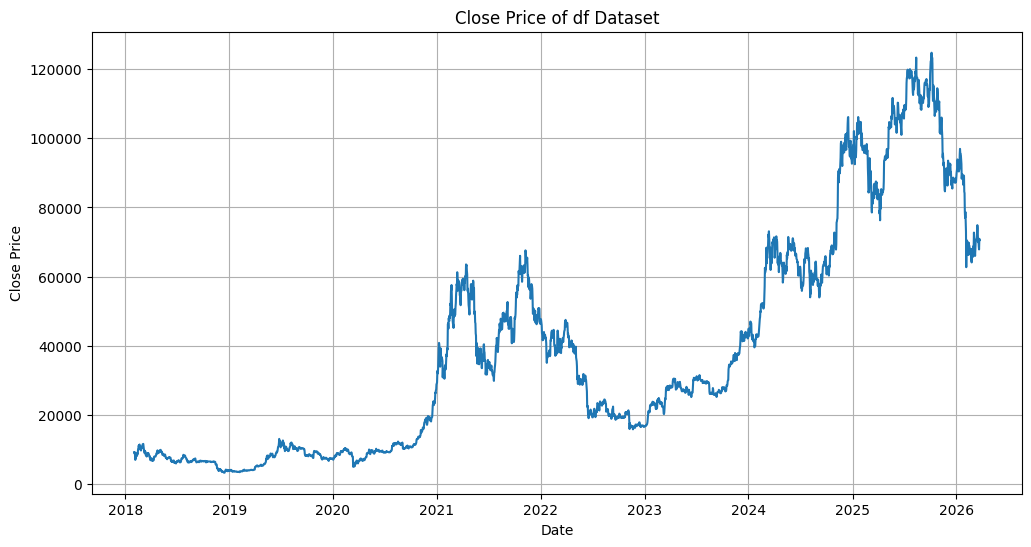

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['BCP'])
plt.title('Close Price of df Dataset')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True)
plt.show()

### Seleziono l'intervallo di interesse: giugno 2022- marzo 2026


In [ ]:
df.tail()

,Date,BCP,FGI
2965,2026-03-20,70522.585938,11.0
2966,2026-03-21,68711.523438,12.0
2967,2026-03-22,67845.210938,10.0
2968,2026-03-23,70914.859375,8.0
2969,2026-03-24,70517.859375,11.0


In [ ]:
start_date = pd.to_datetime('2022-06-22')
end_date = pd.to_datetime('2026-03-23')

df_filtered = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)].copy()

print("Filtered DataFrame (df_filtered) from November 2018 to January 2023:")
print(df_filtered.head())
print(df_filtered.tail())

Filtered DataFrame (df_filtered) from November 2018 to January 2023:
           Date           BCP   FGI
1599 2022-06-22  19987.029297  11.0
1600 2022-06-23  21085.876953  11.0
1601 2022-06-24  21231.656250  11.0
1602 2022-06-25  21502.337891  14.0
1603 2022-06-26  21027.294922  14.0
           Date           BCP   FGI
2964 2026-03-19  69912.789062  23.0
2965 2026-03-20  70522.585938  11.0
2966 2026-03-21  68711.523438  12.0
2967 2026-03-22  67845.210938  10.0
2968 2026-03-23  70914.859375   8.0


In [ ]:
df_filtered = df_filtered.reset_index(drop=True)
print(df_filtered.head())

        Date           BCP   FGI
0 2022-06-22  19987.029297  11.0
1 2022-06-23  21085.876953  11.0
2 2022-06-24  21231.656250  11.0
3 2022-06-25  21502.337891  14.0
4 2022-06-26  21027.294922  14.0


In [ ]:
df = df_filtered

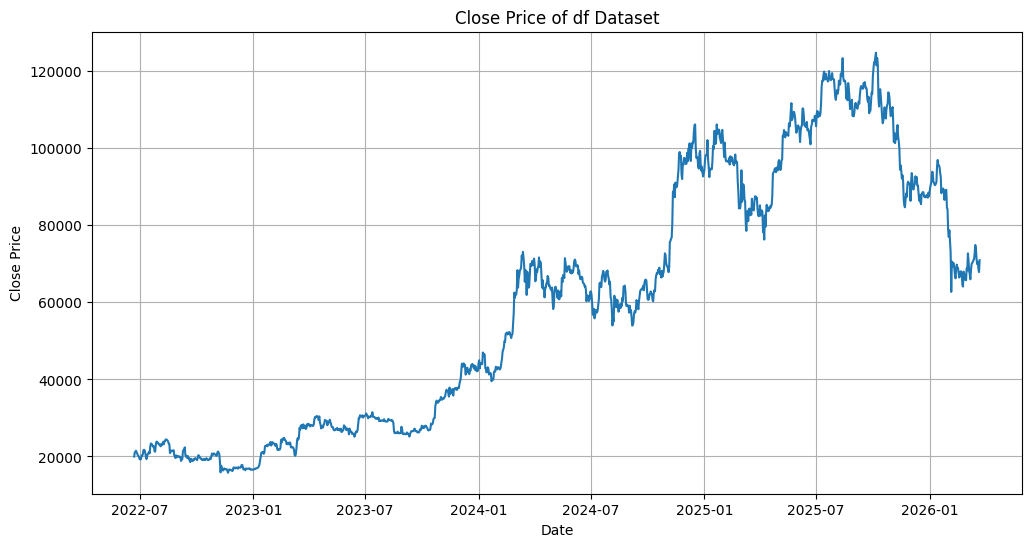

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['BCP'])
plt.title('Close Price of df Dataset')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True)
plt.show()

## LPPLS Bubbles Indicator

In [3]:
import pandas as pd
df = pd.read_csv('dfA.csv')
print(df.head())
print(df.tail())

         Date           BCP   FGI  log_price  t  lppls_score  lppls_r2_score  \
0  2022-06-22  19987.029297  11.0   9.902839  0          0.0             0.0   
1  2022-06-23  21085.876953  11.0   9.956359  1          0.0             0.0   
2  2022-06-24  21231.656250  11.0   9.963249  2          0.0             0.0   
3  2022-06-25  21502.337891  14.0   9.975917  3          0.0             0.0   
4  2022-06-26  21027.294922  14.0   9.953577  4          0.0             0.0   

   lppls_urgency  lppls_tc_median  lppls_days_to_tc  ...  \
0            0.0              NaN               NaN  ...   
1            0.0              NaN               NaN  ...   
2            0.0              NaN               NaN  ...   
3            0.0              NaN               NaN  ...   
4            0.0              NaN               NaN  ...   

   lppls_score_tc_smooth_smooth  lppls_urgency_smooth_tc_smooth  \
0                           0.0                             0.0   
1                       

In [4]:
df['Date'] = pd.to_datetime(df['Date'])

### Nuova versione solo con R2 e VALID FITS

In [ ]:
import numpy as np
import pandas as pd
from lppls import lppls
from tqdm.notebook import tqdm

# ==============================
# PARAMETERS
# ==============================
MAX_WINDOW_SIZE = 210
MIN_WINDOW_SIZE = 30
WINDOW_STEP = 15

N_FITS = 15          # increased from 5
MAX_SEARCHES = 5

MIN_TC_DAYS = 0
MAX_TC_DAYS = 180

M_MIN, M_MAX = 0.01, 0.99
OMEGA_MIN, OMEGA_MAX = 4.0, 17.0

SMOOTH_WINDOW = 25
TC_SMOOTH_WINDOW = 20
NORM_WINDOW = 365

W_R2 = 0.60
W_URGENCY = 0.40

FIT_WEIGHT_SCALE = 10


# ==============================
# HELPER FUNCTIONS
# ==============================
def lppls_function(t, tc, m, w, a, b, c, phi):
    dt = np.maximum(tc - t, 1e-6)
    return a + b * (dt ** m) + c * (dt ** m) * np.cos(w * np.log(dt) + phi)


def compute_r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1 - ss_res / ss_tot if ss_tot > 0 else 0.0


def urgency_exp(days_to_tc, scale=90):
    """
    Smooth urgency transformation.
    High when tc is close, lower when tc is far.
    """
    if pd.isna(days_to_tc):
        return 0.0

    days_to_tc = max(days_to_tc, 0)
    return float(np.exp(-days_to_tc / scale))


# ==============================
# PREPARE DATA
# ==============================
df = df.copy()

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

if 'log_price' not in df.columns:
    df['log_price'] = np.log(df['BCP'])

if 't' not in df.columns:
    df['t'] = np.arange(len(df))

# ==============================
# OUTPUT COLUMNS
# ==============================
output_cols = [
    'lppls_score_raw',
    'lppls_score',
    'lppls_r2_score',
    'lppls_urgency',
    'lppls_fit_weight',
    'lppls_tc_median',
    'lppls_days_to_tc',
    'lppls_valid_fits'
]

for col in output_cols:
    df[col] = np.nan

df['lppls_score_raw'] = 0.0
df['lppls_score'] = 0.0
df['lppls_r2_score'] = 0.0
df['lppls_urgency'] = 0.0
df['lppls_fit_weight'] = 0.0
df['lppls_valid_fits'] = 0


# ==============================
# MAIN LOOP
# ==============================
print("Starting fixed LPPLS score: R² + smoothed urgency + fit-density weighting")

for i in tqdm(range(MAX_WINDOW_SIZE, len(df)), desc="LPPLS fixed score"):

    current_t = df.loc[i, 't']

    tc_list = []
    r2_list = []

    for window_size in range(MIN_WINDOW_SIZE, MAX_WINDOW_SIZE + 1, WINDOW_STEP):

        window = df.iloc[i - window_size:i]

        observations = np.array([
            window['t'].values,
            window['log_price'].values
        ])

        model = lppls.LPPLS(observations=observations)

        for _ in range(N_FITS):

            try:
                fit_result = model.fit(max_searches=MAX_SEARCHES)

                if not isinstance(fit_result, tuple) or len(fit_result) < 7:
                    continue

                tc, m, w, a, b, c, phi = fit_result[:7]

                days_to_tc = tc - current_t

                # ------------------------------
                # Structural filters
                # ------------------------------
                if days_to_tc < MIN_TC_DAYS:
                    continue

                if b >= 0:
                    continue

                if not (M_MIN < m < M_MAX):
                    continue

                if not (OMEGA_MIN < w < OMEGA_MAX):
                    continue

                # ------------------------------
                # R²
                # ------------------------------
                y_true = window['log_price'].values
                y_pred = lppls_function(
                    window['t'].values,
                    tc, m, w, a, b, c, phi
                )

                r2 = compute_r2(y_true, y_pred)
                r2 = np.clip(r2, 0, 1)

                tc_list.append(tc)
                r2_list.append(r2)

            except Exception:
                continue

    # ==============================
    # DAILY AGGREGATION
    # ==============================
    n_valid = len(tc_list)
    df.loc[i, 'lppls_valid_fits'] = n_valid

    # No hard MIN_VALID_FITS cutoff anymore
    if n_valid == 0:
        continue

    tc_array = np.array(tc_list)
    r2_array = np.array(r2_list)

    r2_score = float(np.mean(r2_array))

    if r2_array.sum() > 0:
        tc_consensus = float(np.average(tc_array, weights=r2_array))
    else:
        tc_consensus = float(np.median(tc_array))

    days_to_tc = tc_consensus - current_t

    urgency = urgency_exp(days_to_tc, scale=MAX_TC_DAYS)

    raw_score = (r2_score ** W_R2) * (urgency ** W_URGENCY)

    # soft confidence penalty instead of hard cutoff
    fit_weight = float(np.tanh(n_valid / FIT_WEIGHT_SCALE))

    score = raw_score * fit_weight

    df.loc[i, 'lppls_score_raw'] = raw_score
    df.loc[i, 'lppls_score'] = score
    df.loc[i, 'lppls_r2_score'] = r2_score
    df.loc[i, 'lppls_urgency'] = urgency
    df.loc[i, 'lppls_fit_weight'] = fit_weight
    df.loc[i, 'lppls_tc_median'] = tc_consensus
    df.loc[i, 'lppls_days_to_tc'] = days_to_tc


# ==============================
# POST-PROCESSING: SMOOTH TC FIRST
# ==============================
df['lppls_tc_median_smooth'] = (
    df['lppls_tc_median']
    .ffill()
    .ewm(span=TC_SMOOTH_WINDOW, adjust=False)
    .mean()
)

df['lppls_days_to_tc_smooth'] = df['lppls_tc_median_smooth'] - df['t']

df['lppls_urgency_smooth_tc'] = df['lppls_days_to_tc_smooth'].apply(
    lambda x: urgency_exp(x, scale=90)
)

# recompute smoother score using smoothed tc urgency
df['lppls_score_tc_smooth'] = (
    (df['lppls_r2_score'] ** W_R2)
    * (df['lppls_urgency_smooth_tc'] ** W_URGENCY)
    * df['lppls_fit_weight']
)

Starting fixed LPPLS score: R² + smoothed urgency + fit-density weighting


LPPLS fixed score:   0%|          | 0/1160 [00:00<?, ?it/s]


Fixed LPPLS score finished.
Signal coverage       : 612 / 1160
Mean valid fits       : 30.27
Mean R² score         : 0.590
Mean urgency          : 0.817
Mean fit weight       : 0.825
Mean final score      : 0.405
Mean days to tc       : 812.1


In [ ]:
from google.colab import files

# Save the DataFrame to a CSV file
df.to_csv('dfA.csv', index=False)

# Download the file
files.download('dfA.csv')

NameError: name 'df' is not defined

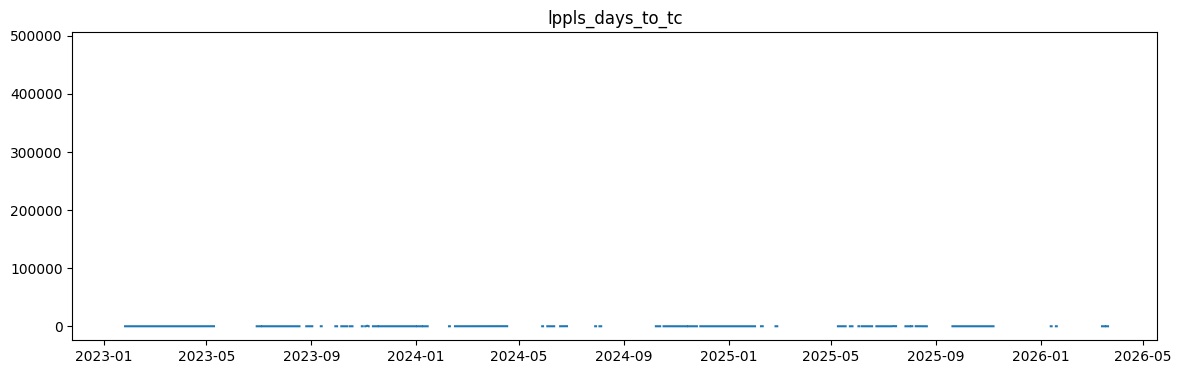

In [ ]:
plt.figure(figsize=(14,4))

plt.plot(df['Date'], df['lppls_days_to_tc'])

plt.title('lppls_days_to_tc')
plt.show()

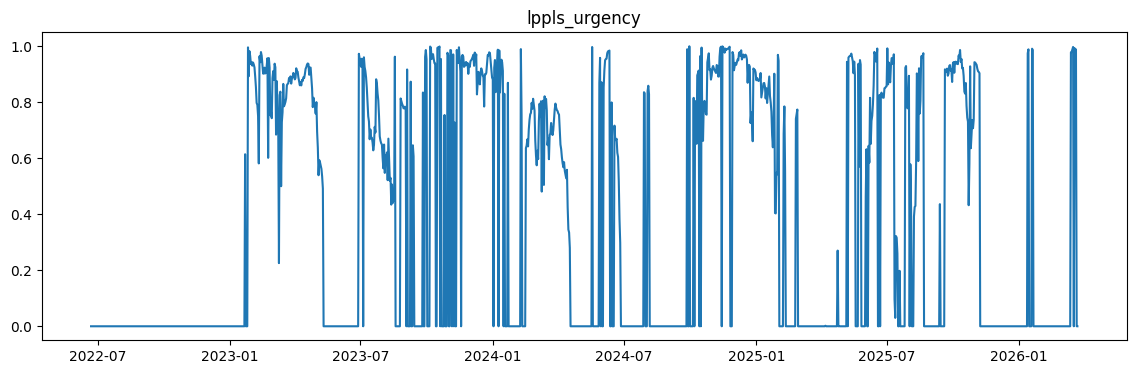

In [ ]:
plt.figure(figsize=(14,4))

plt.plot(df['Date'], df['lppls_urgency'])

plt.title('lppls_urgency')
plt.show()

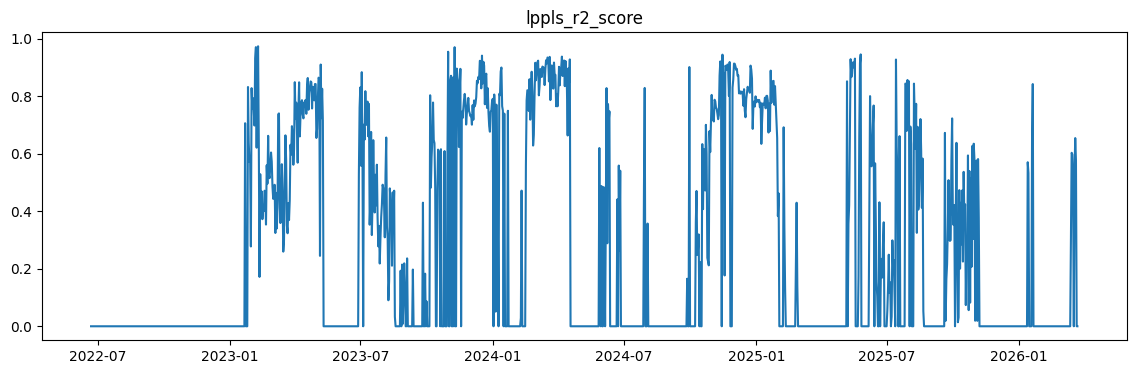

In [ ]:
plt.figure(figsize=(14,4))

plt.plot(df['Date'], df['lppls_r2_score'])

plt.title('lppls_r2_score')
plt.show()

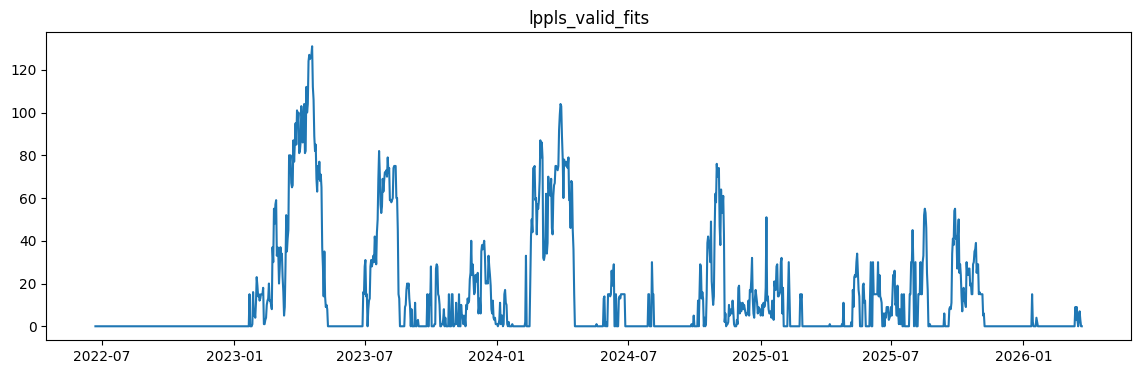

In [ ]:
plt.figure(figsize=(14,4))

plt.plot(df['Date'], df['lppls_valid_fits'])

plt.title('lppls_valid_fits')
plt.show()

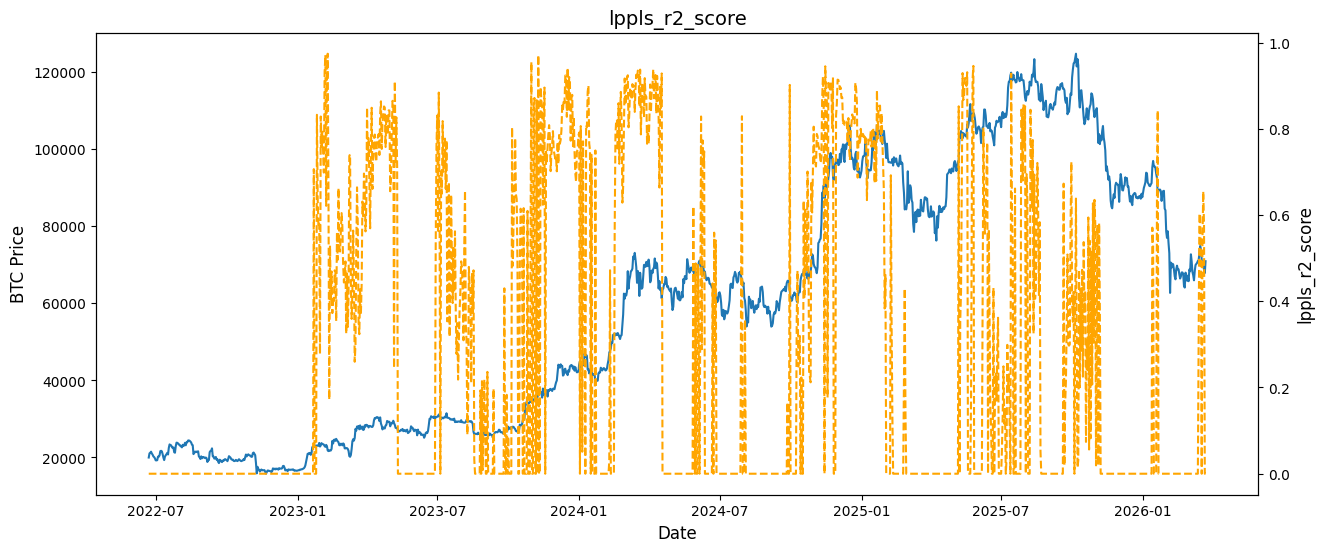

In [ ]:
import matplotlib.pyplot as plt

# ==============================
# PREP DATA
# ==============================
df_plot = df.copy()


# ==============================
# PLOT
# ==============================
fig, ax1 = plt.subplots(figsize=(15,6))

# --- PRICE ---
ax1.plot(df_plot['Date'], df_plot['BCP'])
ax1.set_ylabel('BTC Price', fontsize=12)
ax1.set_xlabel('Date', fontsize=12)

# --- SCORE ---
ax2 = ax1.twinx()
ax2.plot(
    df_plot['Date'],
    df_plot['lppls_r2_score'],
    linestyle='--',
    color='orange'
)
ax2.set_ylabel('lppls_r2_score', fontsize=12)

# --- TITLE ---
plt.title('lppls_r2_score', fontsize=14)

plt.show()

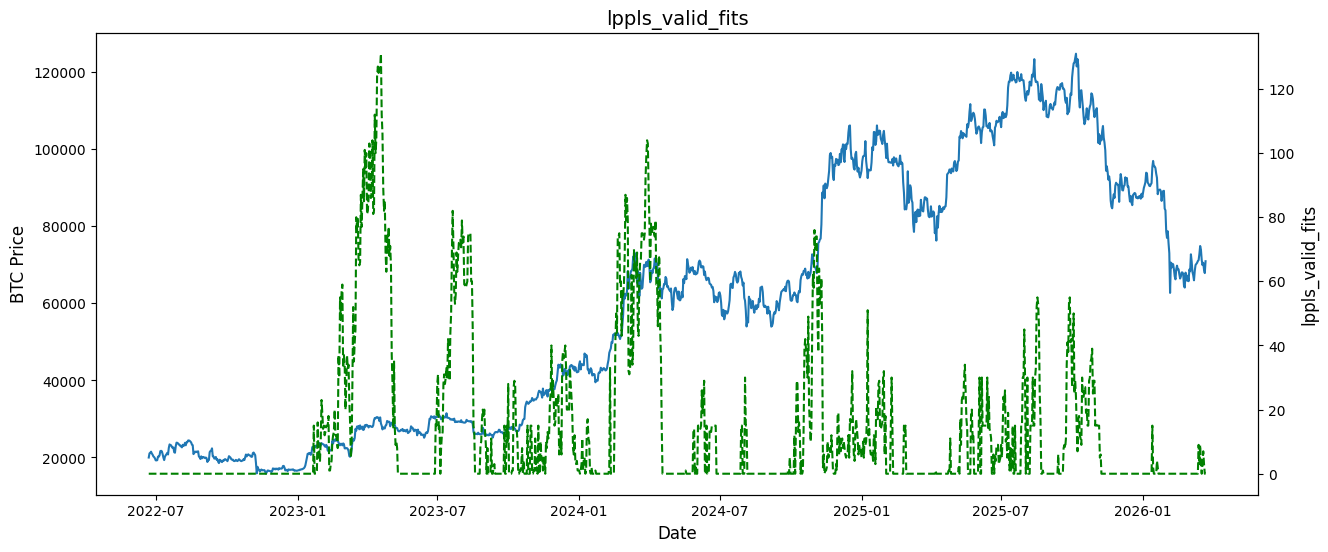

In [ ]:
import matplotlib.pyplot as plt

# ==============================
# PREP DATA
# ==============================
df_plot = df.copy()


# ==============================
# PLOT
# ==============================
fig, ax1 = plt.subplots(figsize=(15,6))

# --- PRICE ---
ax1.plot(df_plot['Date'], df_plot['BCP'])
ax1.set_ylabel('BTC Price', fontsize=12)
ax1.set_xlabel('Date', fontsize=12)

# --- SCORE ---
ax2 = ax1.twinx()
ax2.plot(
    df_plot['Date'],
    df_plot['lppls_valid_fits'],
    linestyle='--',
    color='green'
)
ax2.set_ylabel('lppls_valid_fits', fontsize=12)

# --- TITLE ---
plt.title('lppls_valid_fits', fontsize=14)

plt.show()

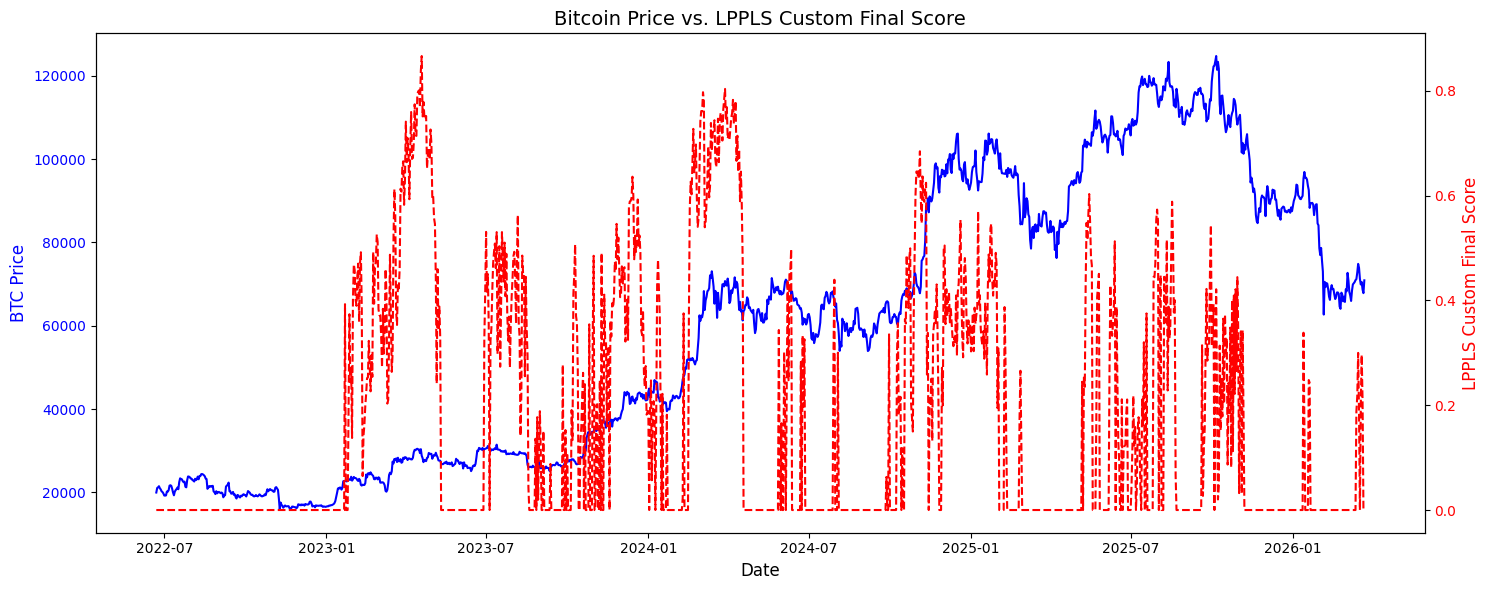

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define exponents for the new final score
R2_EXPONENT = 0.7
FIT_WEIGHT_EXPONENT = 0.3

# Calculate the new lppls_final_score
# We will use lppls_fit_weight as a proxy for the normalized valid fits
# and handle potential NaNs before calculation
df['lppls_r2_score_filled'] = df['lppls_r2_score'].fillna(0)
df['lppls_valid_fits_filled'] = df['lppls_valid_fits'].fillna(0) / 150

df['lppls_custom_final_score'] = (df['lppls_r2_score_filled'] ** R2_EXPONENT) * \
                               (df['lppls_valid_fits_filled'] ** FIT_WEIGHT_EXPONENT)

# ==============================
# PREP DATA FOR PLOTTING
# ==============================
df_plot = df.copy()

# ==============================
# PLOT THE RESULTS
# ==============================
fig, ax1 = plt.subplots(figsize=(15,6))

# --- PRICE ---
ax1.plot(df_plot['Date'], df_plot['BCP'], color='blue')
ax1.set_ylabel('BTC Price', fontsize=12, color='blue')
ax1.set_xlabel('Date', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')

# --- CUSTOM FINAL SCORE ---
ax2 = ax1.twinx()
ax2.plot(
    df_plot['Date'],
    df_plot['lppls_custom_final_score'],
    linestyle='--',
    color='red'
)
ax2.set_ylabel('LPPLS Custom Final Score', fontsize=12, color='red')
ax2.tick_params(axis='y', labelcolor='red')

# --- TITLE ---
plt.title('Bitcoin Price vs. LPPLS Custom Final Score', fontsize=14)

fig.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()


### Signal regularization

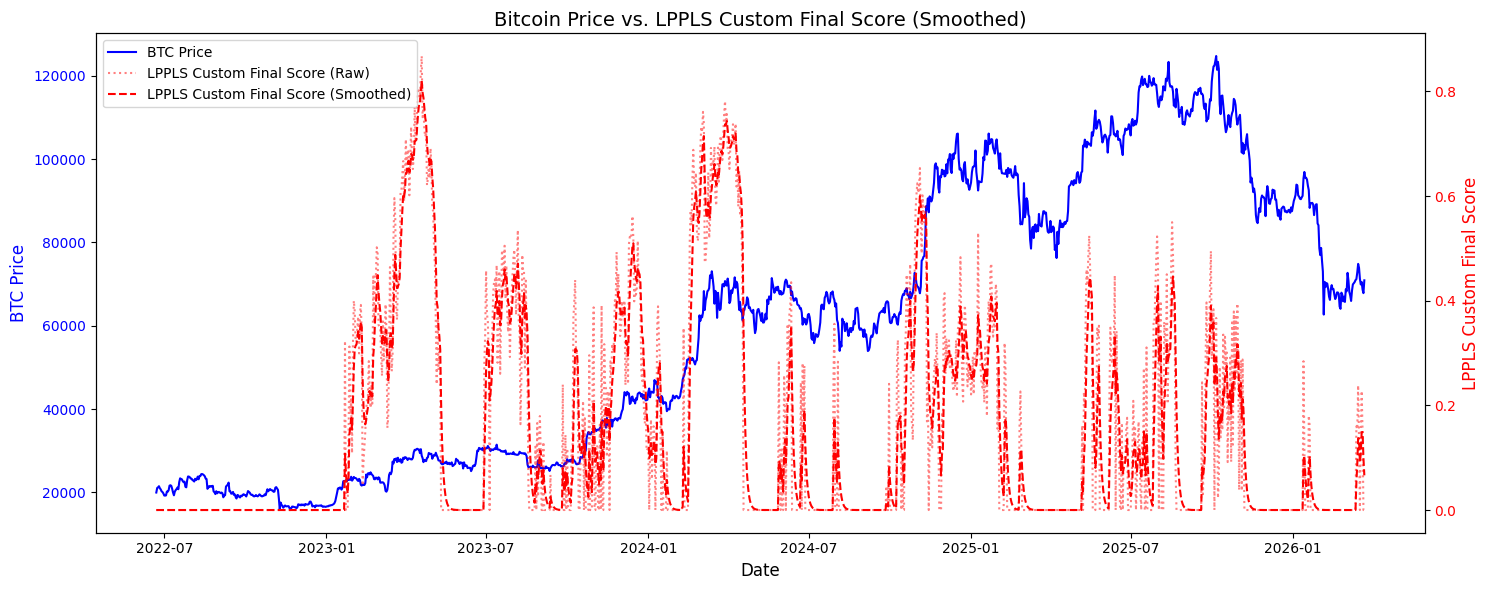

In [5]:
import matplotlib.pyplot as plt

SMOOTH_WINDOW = 5

df['lppls_custom_final_score_smooth'] = (
    df['lppls_custom_final_score']
    .ewm(span=SMOOTH_WINDOW, adjust=False)
    .mean()
)

# ==============================
# PREP DATA FOR PLOTTING
# ==============================
df_plot = df.copy()

# ==============================
# PLOT THE RESULTS
# ==============================
fig, ax1 = plt.subplots(figsize=(15,6))

# --- PRICE ---
ax1.plot(df_plot['Date'], df_plot['BCP'], color='blue', label='BTC Price')
ax1.set_ylabel('BTC Price', fontsize=12, color='blue')
ax1.set_xlabel('Date', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')

# --- CUSTOM FINAL SCORE ---
ax2 = ax1.twinx()
ax2.plot(
    df_plot['Date'],
    df_plot['lppls_custom_final_score'],
    linestyle=':',
    color='red', alpha=0.5, label='LPPLS Custom Final Score (Raw)'
)
ax2.plot(
    df_plot['Date'],
    df_plot['lppls_custom_final_score_smooth'],
    linestyle='--',
    color='red', label='LPPLS Custom Final Score (Smoothed)'
)
ax2.set_ylabel('LPPLS Custom Final Score', fontsize=12, color='red')
ax2.tick_params(axis='y', labelcolor='red')

# --- TITLE ---
plt.title('Bitcoin Price vs. LPPLS Custom Final Score (Smoothed)', fontsize=14)

# Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

fig.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()


## Strategies su DatasetA

In [15]:
start_date = pd.to_datetime('2023-01-01')
df = df[df['Date'] >= start_date].reset_index(drop=True)
print(df.head())
print(df.tail())

        Date           BCP        FGI  log_price    t  lppls_score  \
0 2023-01-01  16625.080078  27.143812   9.718668  193          0.0   
1 2023-01-02  16688.470703  27.117665   9.722473  194          0.0   
2 2023-01-03  16679.857422  26.914453   9.721957  195          0.0   
3 2023-01-04  16863.238281  27.293643   9.732891  196          0.0   
4 2023-01-05  16836.736328  27.603890   9.731318  197          0.0   

   lppls_r2_score  lppls_urgency  lppls_tc_median  lppls_days_to_tc  ...  \
0             0.0            0.0              NaN               NaN  ...   
1             0.0            0.0              NaN               NaN  ...   
2             0.0            0.0              NaN               NaN  ...   
3             0.0            0.0              NaN               NaN  ...   
4             0.0            0.0              NaN               NaN  ...   

   equity_position_bh  trade_position_80_bh  ret_position_80_bh  \
0            0.831793                   0.0            

In [8]:
dfA = df

In [ ]:
df = dfA

In [11]:
df['bubble_score']  = df['lppls_custom_final_score_smooth']

In [12]:
FGI_SMOOTH_WINDOW = 10
df['FGI'] = df['FGI'].ewm(span=FGI_SMOOTH_WINDOW, adjust=False).mean()
print('FGI smoothed with a 10-day EWMA.')

FGI smoothed with a 10-day EWMA.


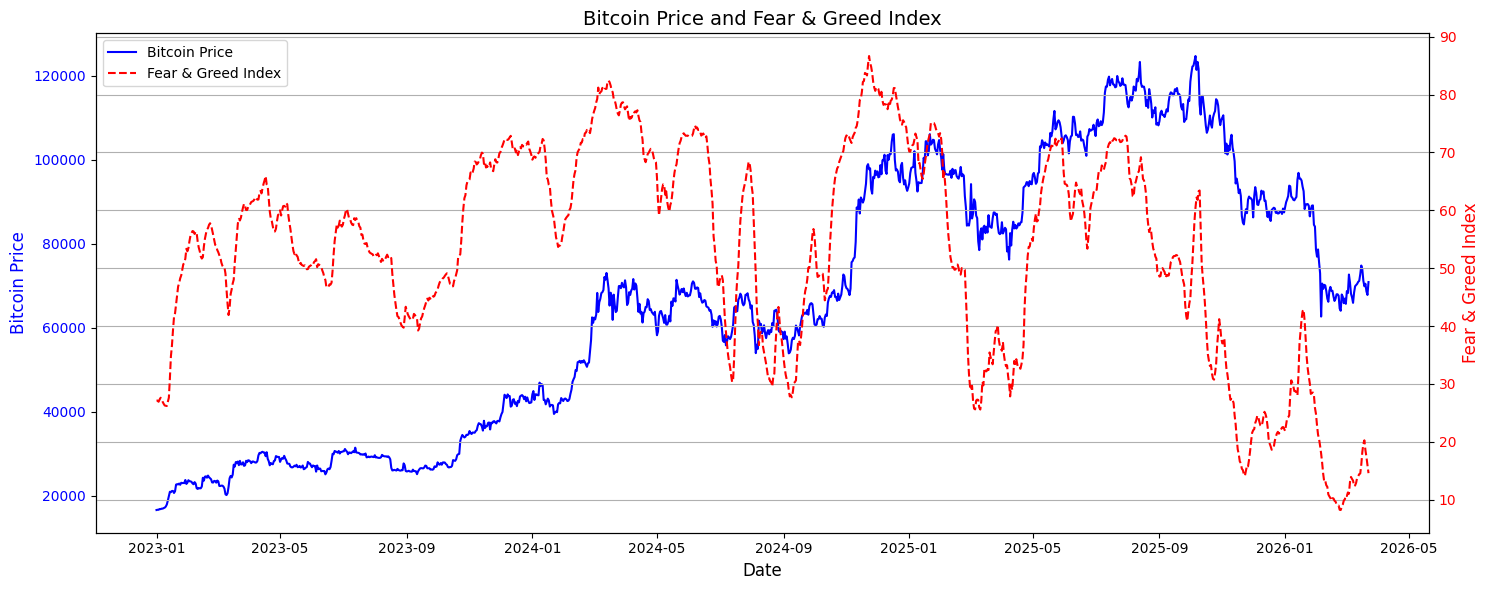

In [16]:
import matplotlib.pyplot as plt

df_plot = df.copy()

fig, ax1 = plt.subplots(figsize=(15,6))

# Plot BCP on the first y-axis
ax1.plot(df_plot['Date'], df_plot['BCP'], color='blue', label='Bitcoin Price')
ax1.set_ylabel('Bitcoin Price', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')

# Create a second y-axis for FGI
ax2 = ax1.twinx()
ax2.plot(df_plot['Date'], df_plot['FGI'], color='red', linestyle='--', label='Fear & Greed Index')
ax2.set_ylabel('Fear & Greed Index', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')

ax1.set_xlabel('Date', fontsize=12)
plt.title('Bitcoin Price and Fear & Greed Index', fontsize=14)

# Add legends from both axes
lines = ax1.get_lines() + ax2.get_lines()
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.grid(True)
plt.tight_layout()
plt.show()

### Strategia con LPPLS bubble score

,Strategy,Final Value,Total Return,Annual Return,Annual Volatility,Sharpe Ratio,Max Drawdown,Calmar Ratio,Average Exposure,Turnover
0,Buy & Hold,4.265535,3.265535,0.568055,0.478954,1.186033,-0.497388,1.142076,1.000000,0.000000
1,Rebalanced Strategy (10d),2.861927,1.861927,0.385526,0.346363,1.113069,-0.419701,0.918572,0.685582,21.718722


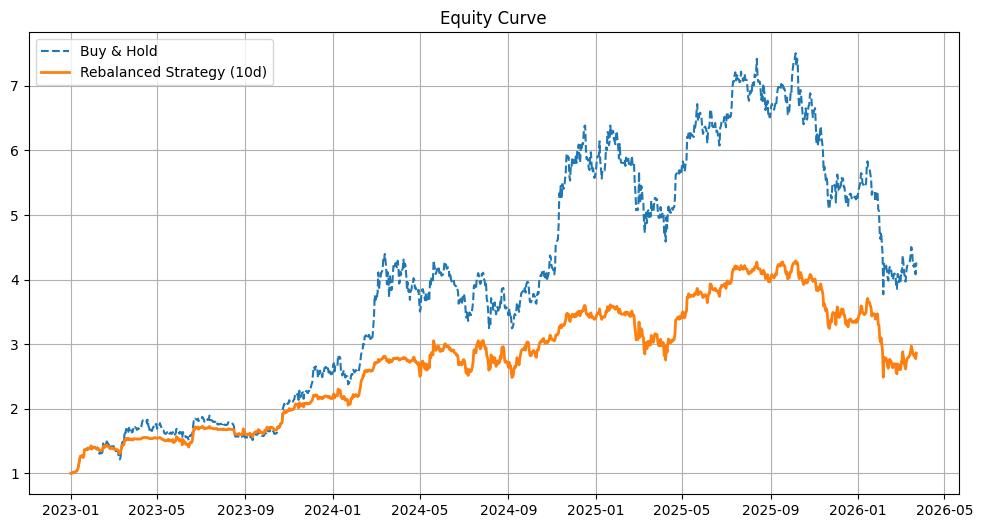

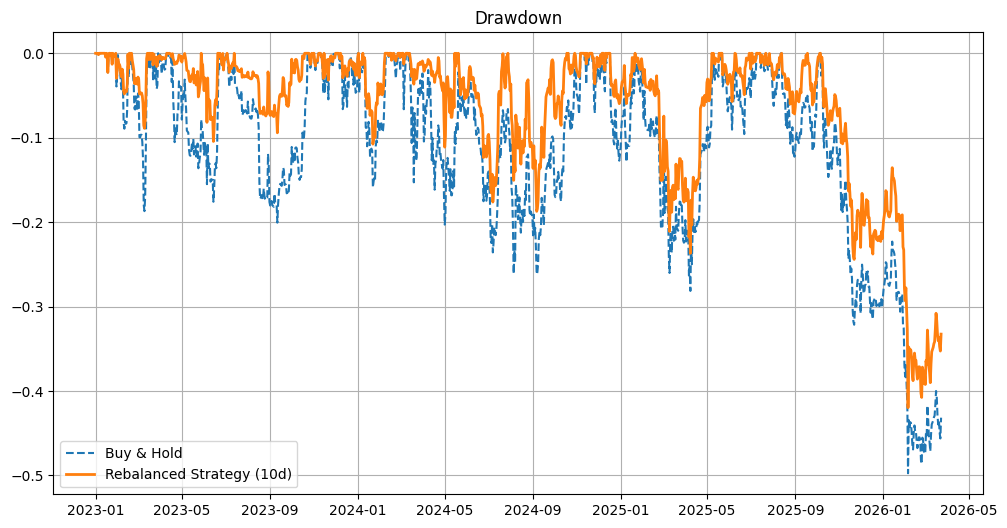

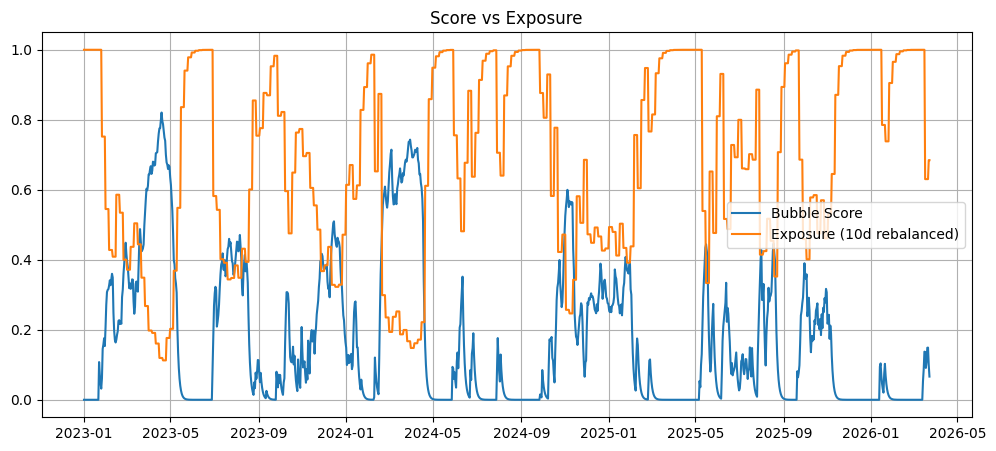

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# SIMPLE STRATEGY WITH PERIODIC REBALANCING
# ============================================================

df = df.copy()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

PRICE_COL = 'BCP'
SCORE_COL = 'bubble_score'

fee = 0.001
REBALANCE_DAYS = 5

# ------------------------------------------------------------
# DATA PREPARATION
# ------------------------------------------------------------

df[PRICE_COL] = df[PRICE_COL].astype(float)
df[SCORE_COL] = df[SCORE_COL].ffill().fillna(0).clip(0, 1)

df['ret'] = df[PRICE_COL].pct_change().fillna(0)

# ============================================================
# STRATEGY: PERIODIC REBALANCING
# ============================================================

# Buy & Hold
df['position_bh'] = 1.0

# Compute target exposure
MAX_EXPOSURE = 1
ALPHA = 0.5

df['target_position'] = MAX_EXPOSURE * (1 - df[SCORE_COL]**ALPHA)

# Initialize actual position
positions = []
current_position = df['target_position'].iloc[0]

for i in range(len(df)):

    # rebalance every N days
    if i % REBALANCE_DAYS == 0:
        current_position = df['target_position'].iloc[i]

    positions.append(current_position)

df['position_strategy'] = positions

# ============================================================
# RETURNS
# ============================================================

def apply_strategy(df, position_col, ret_col='ret', fee=0.001):
    out = df.copy()

    trade_col = f'trade_{position_col}'
    ret_strategy_col = f'ret_{position_col}'
    equity_col = f'equity_{position_col}'

    # trades only occur at rebalancing points now
    out[trade_col] = out[position_col].diff().abs().fillna(0)

    out[ret_strategy_col] = (
        out[position_col].shift(1).fillna(out[position_col]) * out[ret_col]
    )

    out[ret_strategy_col] -= out[trade_col] * fee

    out[equity_col] = (1 + out[ret_strategy_col]).cumprod()

    return out, ret_strategy_col, equity_col, trade_col


df, ret_bh, equity_bh, trade_bh = apply_strategy(df, 'position_bh', fee=fee)
df, ret_strat, equity_strat, trade_strat = apply_strategy(df, 'position_strategy', fee=fee)

# ============================================================
# METRICS
# ============================================================

def compute_drawdown(equity):
    peak = equity.cummax()
    return (equity - peak) / peak


def compute_metrics(df, ret_col, equity_col, trade_col, position_col, name):
    ret = df[ret_col]
    equity = df[equity_col]

    total_return = equity.iloc[-1] / equity.iloc[0] - 1
    ann_return = (1 + total_return) ** (365 / len(df)) - 1
    ann_vol = ret.std() * np.sqrt(365)
    sharpe = ann_return / ann_vol if ann_vol != 0 else np.nan

    dd = compute_drawdown(equity)
    max_dd = dd.min()
    calmar = ann_return / abs(max_dd) if max_dd != 0 else np.nan

    return {
        'Strategy': name,
        'Final Value': equity.iloc[-1],
        'Total Return': total_return,
        'Annual Return': ann_return,
        'Annual Volatility': ann_vol,
        'Sharpe Ratio': sharpe,
        'Max Drawdown': max_dd,
        'Calmar Ratio': calmar,
        'Average Exposure': df[position_col].mean(),
        'Turnover': df[trade_col].sum()
    }


metrics = pd.DataFrame([
    compute_metrics(df, ret_bh, equity_bh, trade_bh, 'position_bh', 'Buy & Hold'),
    compute_metrics(df, ret_strat, equity_strat, trade_strat, 'position_strategy', 'Rebalanced Strategy (10d)')
])

display(metrics)

# ============================================================
# DRAWDOWNS
# ============================================================

df['dd_bh'] = compute_drawdown(df[equity_bh])
df['dd_strategy'] = compute_drawdown(df[equity_strat])

# ============================================================
# PLOTS
# ============================================================

# Equity
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df[equity_bh], label='Buy & Hold', linestyle='--')
plt.plot(df['Date'], df[equity_strat], label='Rebalanced Strategy (10d)', linewidth=2)
plt.title('Equity Curve')
plt.legend()
plt.grid(True)
plt.show()

# Drawdown
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['dd_bh'], label='Buy & Hold', linestyle='--')
plt.plot(df['Date'], df['dd_strategy'], label='Rebalanced Strategy (10d)', linewidth=2)
plt.title('Drawdown')
plt.legend()
plt.grid(True)
plt.show()

# Exposure
plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df[SCORE_COL], label='Bubble Score')
plt.plot(df['Date'], df['position_strategy'], label='Exposure (10d rebalanced)')
plt.title('Score vs Exposure')
plt.legend()
plt.grid(True)
plt.show()

### Strategia con FGI

,Strategy,Final Value,Total Return,Annual Return,Annual Volatility,Sharpe Ratio,Max Drawdown,Calmar Ratio,Average Exposure,Turnover
0,Buy & Hold,4.265535,3.265535,0.568055,0.478954,1.186033,-0.497388,1.142076,1.000000,0.000000
1,80% Buy & Hold,3.383887,2.383887,0.459410,0.383163,1.198994,-0.419264,1.095755,0.800000,0.000000
2,FGI Strategy,2.077984,1.077984,0.254597,0.248555,1.024307,-0.353509,0.720199,0.469231,9.005109


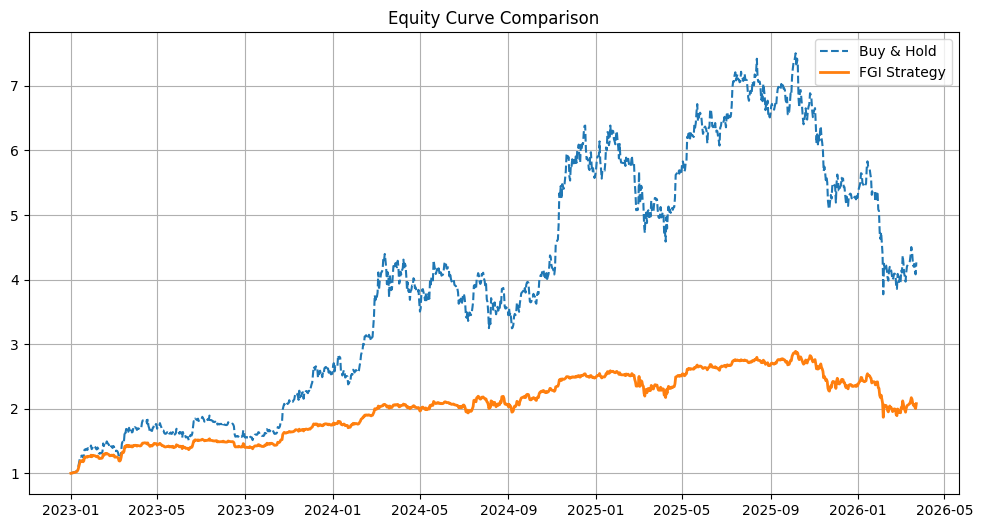

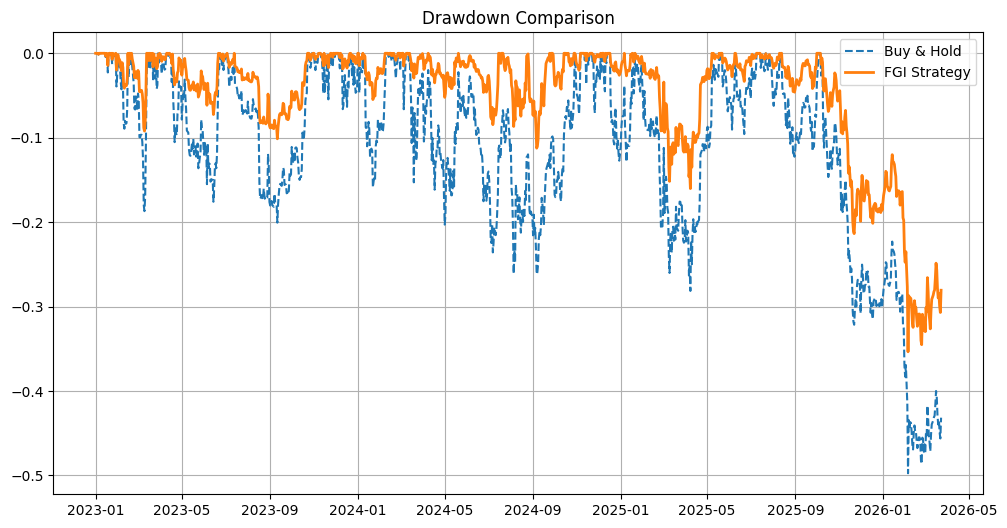

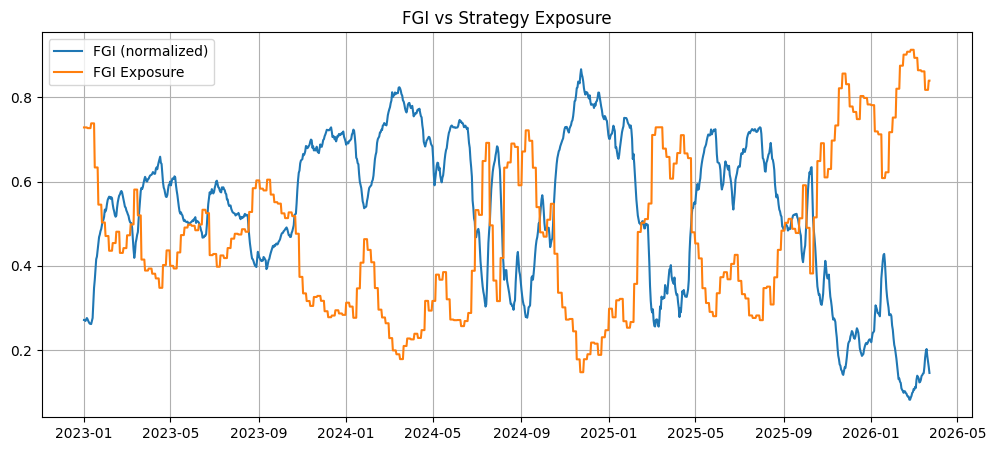

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# FGI-BASED STRATEGY (ANALOGOUS TO BUBBLE SCORE)
# ============================================================

df = df.copy()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

PRICE_COL = 'BCP'
FGI_COL = 'FGI'

fee = 0.001
REBALANCE_DAYS = 5

MAX_EXPOSURE = 1
ALPHA = 1   # same nonlinear mapping used before

# ------------------------------------------------------------
# DATA PREPARATION
# ------------------------------------------------------------

df[PRICE_COL] = df[PRICE_COL].astype(float)
df[FGI_COL] = df[FGI_COL].ffill().fillna(50)

df['ret'] = df[PRICE_COL].pct_change().fillna(0)

# ============================================================
# NORMALIZE FGI
# ============================================================

df['fgi_norm'] = (df[FGI_COL] / 100).clip(0, 1)

# ============================================================
# TARGET EXPOSURE (SAME FORMULA)
# ============================================================

df['target_position_fgi'] = MAX_EXPOSURE * (1 - df['fgi_norm']**ALPHA)

# ============================================================
# PERIODIC REBALANCING
# ============================================================

positions = []
current_position = df['target_position_fgi'].iloc[0]

for i in range(len(df)):

    if i % REBALANCE_DAYS == 0:
        current_position = df['target_position_fgi'].iloc[i]

    positions.append(current_position)

df['position_fgi'] = positions

# ============================================================
# RETURNS
# ============================================================

def apply_strategy(df, position_col, ret_col='ret', fee=0.001):
    out = df.copy()

    trade_col = f'trade_{position_col}'
    ret_strategy_col = f'ret_{position_col}'
    equity_col = f'equity_{position_col}'

    out[trade_col] = out[position_col].diff().abs().fillna(0)

    out[ret_strategy_col] = (
        out[position_col].shift(1).fillna(out[position_col]) * out[ret_col]
    )

    out[ret_strategy_col] -= out[trade_col] * fee

    out[equity_col] = (1 + out[ret_strategy_col]).cumprod()

    return out, ret_strategy_col, equity_col, trade_col


# Buy & Hold
df['position_bh'] = 1.0
df, ret_bh, equity_bh, trade_bh = apply_strategy(df, 'position_bh', fee=fee)

# 80% Buy & Hold (fair comparison)
df['position_80_bh'] = 0.80
df, ret_80_bh, equity_80_bh, trade_80_bh = apply_strategy(df, 'position_80_bh', fee=fee)

# FGI strategy
df, ret_fgi, equity_fgi, trade_fgi = apply_strategy(df, 'position_fgi', fee=fee)

# ============================================================
# METRICS
# ============================================================

def compute_drawdown(equity):
    peak = equity.cummax()
    return (equity - peak) / peak


def compute_metrics(df, ret_col, equity_col, trade_col, position_col, name):
    ret = df[ret_col]
    equity = df[equity_col]

    total_return = equity.iloc[-1] / equity.iloc[0] - 1
    ann_return = (1 + total_return) ** (365 / len(df)) - 1
    ann_vol = ret.std() * np.sqrt(365)
    sharpe = ann_return / ann_vol if ann_vol != 0 else np.nan

    dd = compute_drawdown(equity)
    max_dd = dd.min()
    calmar = ann_return / abs(max_dd) if max_dd != 0 else np.nan

    return {
        'Strategy': name,
        'Final Value': equity.iloc[-1],
        'Total Return': total_return,
        'Annual Return': ann_return,
        'Annual Volatility': ann_vol,
        'Sharpe Ratio': sharpe,
        'Max Drawdown': max_dd,
        'Calmar Ratio': calmar,
        'Average Exposure': df[position_col].mean(),
        'Turnover': df[trade_col].sum()
    }


metrics = pd.DataFrame([
    compute_metrics(df, ret_bh, equity_bh, trade_bh, 'position_bh', 'Buy & Hold'),
    compute_metrics(df, ret_80_bh, equity_80_bh, trade_80_bh, 'position_80_bh', '80% Buy & Hold'),
    compute_metrics(df, ret_fgi, equity_fgi, trade_fgi, 'position_fgi', 'FGI Strategy')
])

display(metrics)

# ============================================================
# DRAWDOWNS
# ============================================================

df['dd_bh'] = compute_drawdown(df[equity_bh])
df['dd_80_bh'] = compute_drawdown(df[equity_80_bh])
df['dd_fgi'] = compute_drawdown(df[equity_fgi])

# ============================================================
# PLOTS
# ============================================================

# Equity comparison
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df[equity_bh], label='Buy & Hold', linestyle='--')
#plt.plot(df['Date'], df[equity_80_bh], label='80% Buy & Hold')
plt.plot(df['Date'], df[equity_fgi], label='FGI Strategy', linewidth=2)
plt.title('Equity Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()

# Drawdown comparison
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['dd_bh'], label='Buy & Hold', linestyle='--')
#plt.plot(df['Date'], df['dd_80_bh'], label='80% Buy & Hold')
plt.plot(df['Date'], df['dd_fgi'], label='FGI Strategy', linewidth=2)
plt.title('Drawdown Comparison')
plt.legend()
plt.grid(True)
plt.show()

# FGI vs exposure
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['fgi_norm'], label='FGI (normalized)')
plt.plot(df['Date'], df['position_fgi'], label='FGI Exposure')
plt.title('FGI vs Strategy Exposure')
plt.legend()
plt.grid(True)
plt.show()

### Strategia LPPLS*FGI con fear exit

,Strategy,Final Value,Total Return,Annual Return,Annual Volatility,Sharpe Ratio,Max Drawdown,Calmar Ratio,Average Exposure,Turnover
0,Buy & Hold,4.265535,3.265535,0.568055,0.478954,1.186033,-0.497388,1.142076,1.000000,0.000000
1,80% Buy & Hold,3.383887,2.383887,0.459410,0.383163,1.198994,-0.419264,1.095755,0.800000,0.000000
2,LPPLS × FGI + Fear Exit,1.945115,0.945115,0.229150,0.216128,1.060250,-0.220362,1.039880,0.462514,12.298265


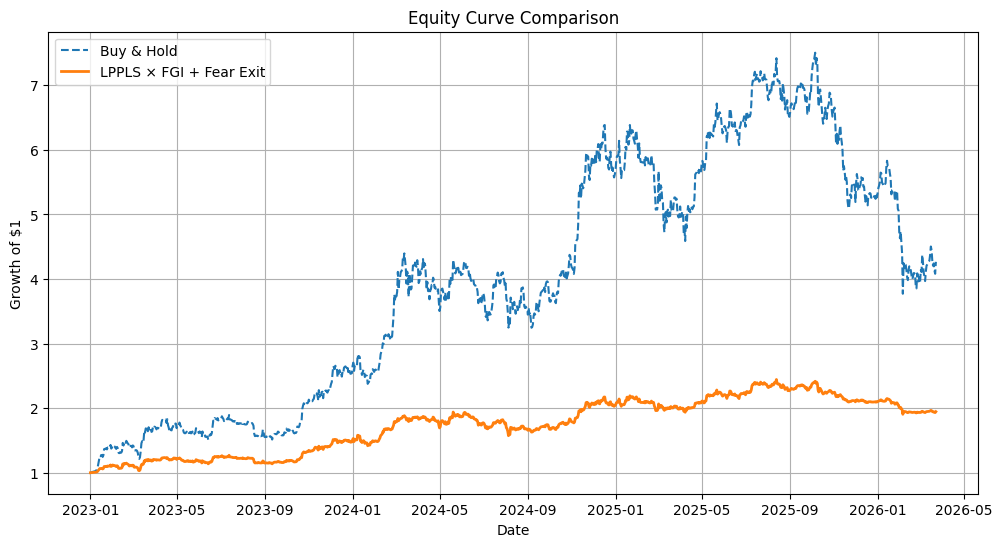

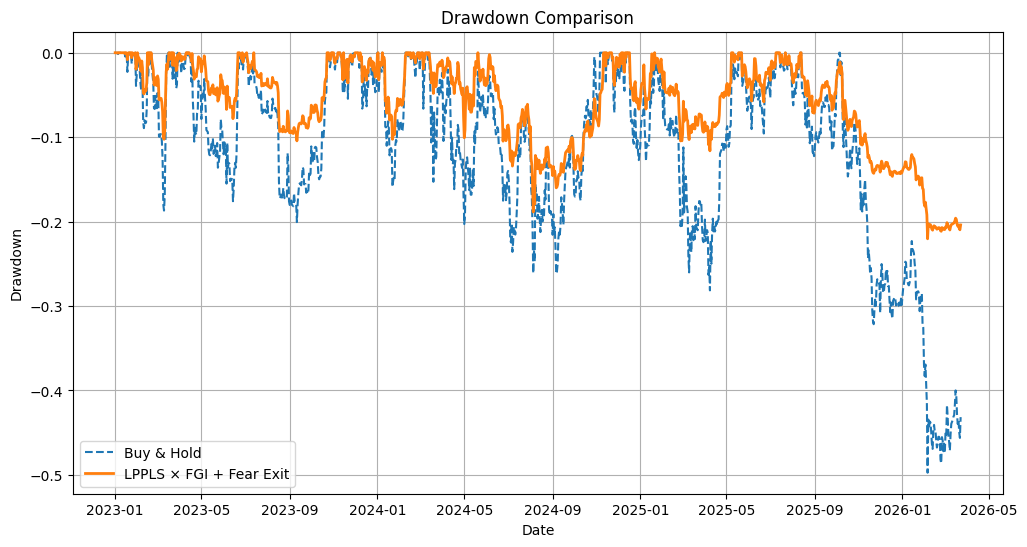

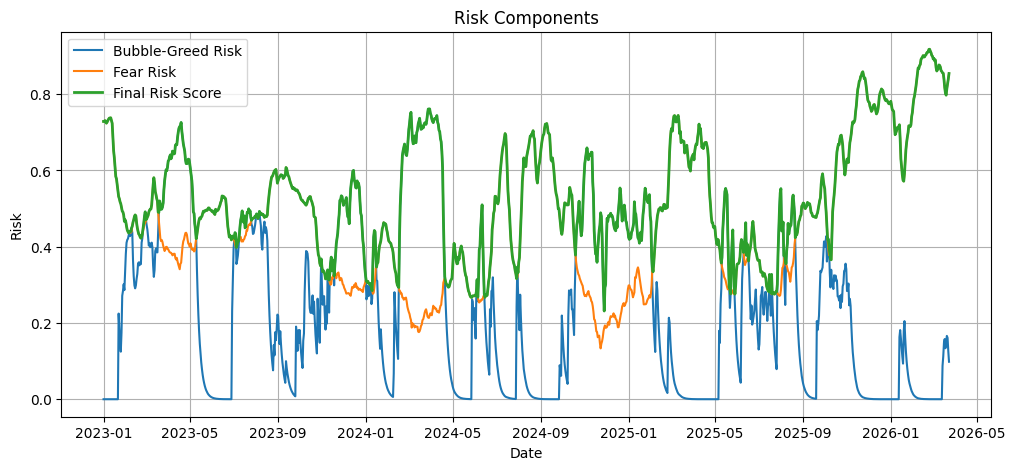

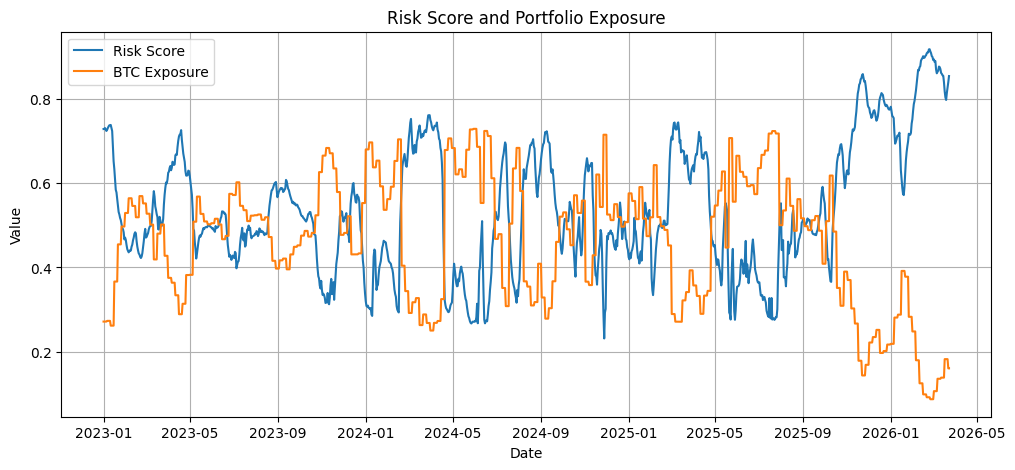

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# LPPLS + FGI STRATEGY WITH FEAR EXIT
# ============================================================

df = df.copy()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

PRICE_COL = 'BCP'
BUBBLE_COL = 'bubble_score'
FGI_COL = 'FGI'

fee = 0.001
REBALANCE_DAYS = 5
MAX_EXPOSURE = 1
ALPHA = 1

# ------------------------------------------------------------
# DATA PREPARATION
# ------------------------------------------------------------

df[PRICE_COL] = df[PRICE_COL].astype(float)
df[BUBBLE_COL] = df[BUBBLE_COL].ffill().fillna(0).clip(0, 1)
df[FGI_COL] = df[FGI_COL].ffill().fillna(50)

df['ret'] = df[PRICE_COL].pct_change().fillna(0)

# ------------------------------------------------------------
# SIGNALS
# ------------------------------------------------------------

df['lppls_score'] = df[BUBBLE_COL]
df['fgi_norm'] = (df[FGI_COL] / 100).clip(0, 1)

# Greed/bubble risk: high when both LPPLS and FGI are high
df['bubble_greed_risk'] = (df['lppls_score'] * df['fgi_norm'])**(0.5)

# Fear risk: high when FGI is low
df['fear_risk'] = 1 - df['fgi_norm']

# Final risk score: risk is high either in euphoric bubble or panic/fear
df['risk_score'] = np.maximum(df['bubble_greed_risk'], df['fear_risk']).clip(0, 1)

# ------------------------------------------------------------
# TARGET EXPOSURE
# ------------------------------------------------------------

df['target_position_risk'] = MAX_EXPOSURE * (1 - df['risk_score']**ALPHA)

# ------------------------------------------------------------
# PERIODIC REBALANCING
# ------------------------------------------------------------

positions = []
current_position = df['target_position_risk'].iloc[0]

for i in range(len(df)):
    if i % REBALANCE_DAYS == 0:
        current_position = df['target_position_risk'].iloc[i]
    positions.append(current_position)

df['position_risk'] = positions

# ------------------------------------------------------------
# APPLY STRATEGY
# ------------------------------------------------------------

def apply_strategy(df, position_col, ret_col='ret', fee=0.001):
    out = df.copy()

    trade_col = f'trade_{position_col}'
    ret_strategy_col = f'ret_{position_col}'
    equity_col = f'equity_{position_col}'

    out[trade_col] = out[position_col].diff().abs().fillna(0)

    out[ret_strategy_col] = (
        out[position_col].shift(1).fillna(out[position_col]) * out[ret_col]
    )

    out[ret_strategy_col] -= out[trade_col] * fee
    out[equity_col] = (1 + out[ret_strategy_col]).cumprod()

    return out, ret_strategy_col, equity_col, trade_col

# ------------------------------------------------------------
# BENCHMARKS
# ------------------------------------------------------------

df['position_bh'] = 1.0
df['position_80_bh'] = 0.80

df, ret_bh, equity_bh, trade_bh = apply_strategy(df, 'position_bh', fee=fee)
df, ret_80_bh, equity_80_bh, trade_80_bh = apply_strategy(df, 'position_80_bh', fee=fee)
df, ret_risk, equity_risk, trade_risk = apply_strategy(df, 'position_risk', fee=fee)

# ------------------------------------------------------------
# METRICS
# ------------------------------------------------------------

def compute_drawdown(equity):
    peak = equity.cummax()
    return (equity - peak) / peak


def compute_metrics(df, ret_col, equity_col, trade_col, position_col, name):
    ret = df[ret_col]
    equity = df[equity_col]

    total_return = equity.iloc[-1] / equity.iloc[0] - 1
    ann_return = (1 + total_return) ** (365 / len(df)) - 1
    ann_vol = ret.std() * np.sqrt(365)
    sharpe = ann_return / ann_vol if ann_vol != 0 else np.nan

    dd = compute_drawdown(equity)
    max_dd = dd.min()
    calmar = ann_return / abs(max_dd) if max_dd != 0 else np.nan

    return {
        'Strategy': name,
        'Final Value': equity.iloc[-1],
        'Total Return': total_return,
        'Annual Return': ann_return,
        'Annual Volatility': ann_vol,
        'Sharpe Ratio': sharpe,
        'Max Drawdown': max_dd,
        'Calmar Ratio': calmar,
        'Average Exposure': df[position_col].mean(),
        'Turnover': df[trade_col].sum()
    }


metrics = pd.DataFrame([
    compute_metrics(df, ret_bh, equity_bh, trade_bh, 'position_bh', 'Buy & Hold'),
    compute_metrics(df, ret_80_bh, equity_80_bh, trade_80_bh, 'position_80_bh', '80% Buy & Hold'),
    compute_metrics(df, ret_risk, equity_risk, trade_risk, 'position_risk', 'LPPLS × FGI + Fear Exit')
])

display(metrics)

# ------------------------------------------------------------
# DRAWDOWNS
# ------------------------------------------------------------

df['dd_bh'] = compute_drawdown(df[equity_bh])
df['dd_80_bh'] = compute_drawdown(df[equity_80_bh])
df['dd_risk'] = compute_drawdown(df[equity_risk])

# ------------------------------------------------------------
# PLOTS
# ------------------------------------------------------------

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df[equity_bh], label='Buy & Hold', linestyle='--')
#plt.plot(df['Date'], df[equity_80_bh], label='80% Buy & Hold')
plt.plot(df['Date'], df[equity_risk], label='LPPLS × FGI + Fear Exit', linewidth=2)
plt.title('Equity Curve Comparison')
plt.xlabel('Date')
plt.ylabel('Growth of $1')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['dd_bh'], label='Buy & Hold', linestyle='--')
#plt.plot(df['Date'], df['dd_80_bh'], label='80% Buy & Hold')
plt.plot(df['Date'], df['dd_risk'], label='LPPLS × FGI + Fear Exit', linewidth=2)
plt.title('Drawdown Comparison')
plt.xlabel('Date')
plt.ylabel('Drawdown')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['bubble_greed_risk'], label='Bubble-Greed Risk')
plt.plot(df['Date'], df['fear_risk'], label='Fear Risk')
plt.plot(df['Date'], df['risk_score'], label='Final Risk Score', linewidth=2)
plt.title('Risk Components')
plt.xlabel('Date')
plt.ylabel('Risk')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['risk_score'], label='Risk Score')
plt.plot(df['Date'], df['position_risk'], label='BTC Exposure')
plt.title('Risk Score and Portfolio Exposure')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

### Stesso con composizione additiva LBS e FGI

,Strategy,Final Value,Total Return,Annual Return,Annual Volatility,Sharpe Ratio,Max Drawdown,Calmar Ratio,Average Exposure,Turnover
0,Buy & Hold,4.265535,3.265535,0.568055,0.478954,1.186033,-0.497388,1.142076,1.000000,0.000000
1,80% Buy & Hold,3.383887,2.383887,0.459410,0.383163,1.198994,-0.419264,1.095755,0.800000,0.000000
2,LPPLS × FGI + Fear Exit,1.961186,0.961186,0.232291,0.208038,1.116579,-0.216275,1.074050,0.444904,10.726513


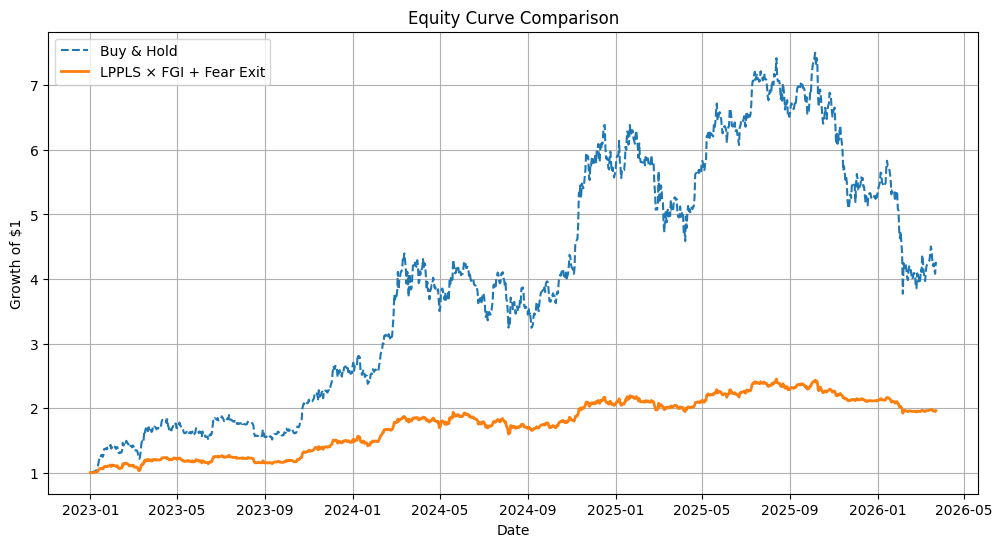

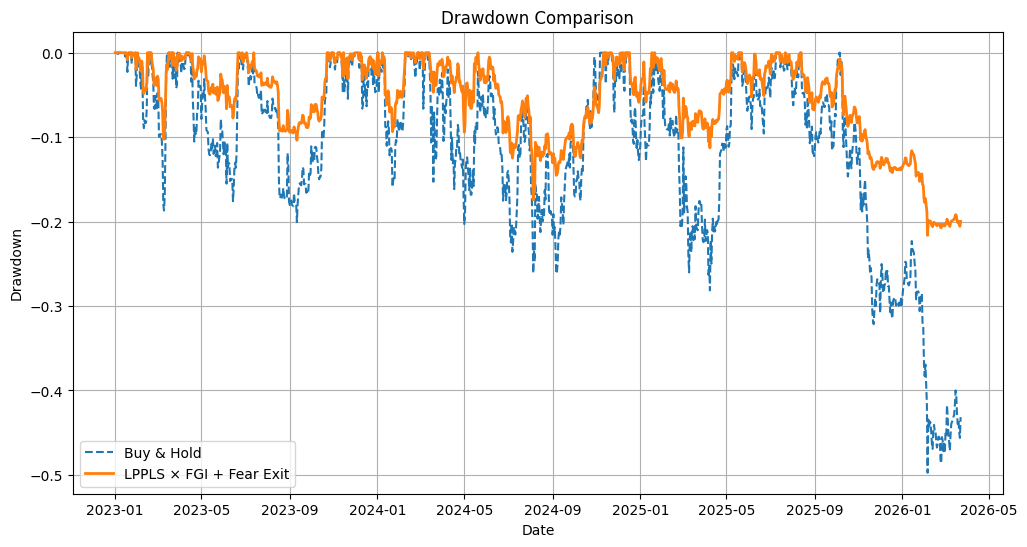

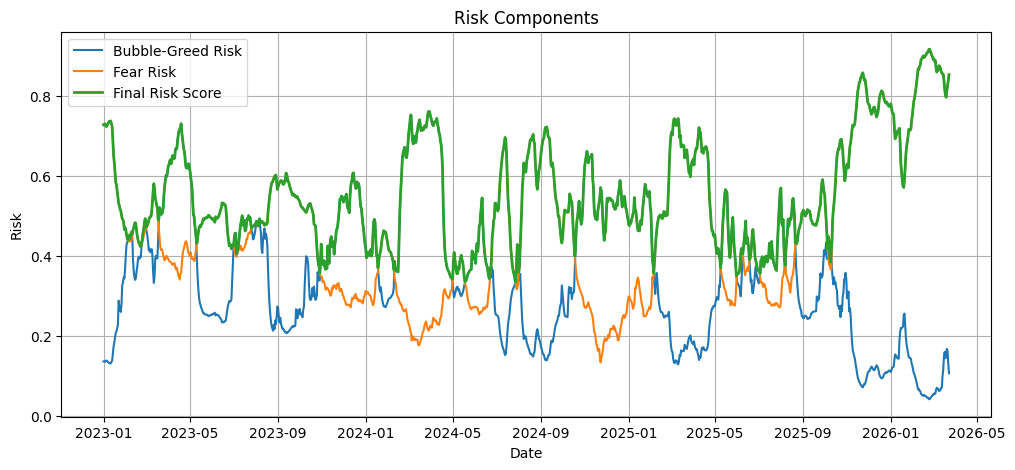

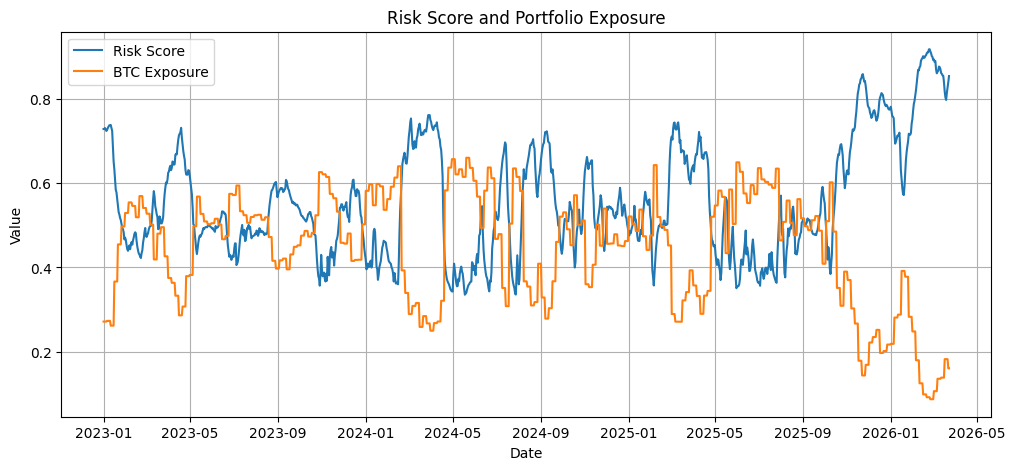

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# LPPLS + FGI STRATEGY WITH FEAR EXIT
# ============================================================

df = df.copy()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

PRICE_COL = 'BCP'
BUBBLE_COL = 'bubble_score'
FGI_COL = 'FGI'

fee = 0.001
REBALANCE_DAYS = 5
MAX_EXPOSURE = 1
ALPHA = 1

# ------------------------------------------------------------
# DATA PREPARATION
# ------------------------------------------------------------

df[PRICE_COL] = df[PRICE_COL].astype(float)
df[BUBBLE_COL] = df[BUBBLE_COL].ffill().fillna(0).clip(0, 1)
df[FGI_COL] = df[FGI_COL].ffill().fillna(50)

df['ret'] = df[PRICE_COL].pct_change().fillna(0)

# ------------------------------------------------------------
# SIGNALS
# ------------------------------------------------------------

df['lppls_score'] = df[BUBBLE_COL]
df['fgi_norm'] = (df[FGI_COL] / 100).clip(0, 1)

# Greed/bubble risk: high when both LPPLS and FGI are high
df['bubble_greed_risk'] = 0.5*df['lppls_score'] + 0.5*df['fgi_norm']

# Fear risk: high when FGI is low
df['fear_risk'] = 1 - df['fgi_norm']

# Final risk score: risk is high either in euphoric bubble or panic/fear
df['risk_score'] = np.maximum(df['bubble_greed_risk'], df['fear_risk']).clip(0, 1)

# ------------------------------------------------------------
# TARGET EXPOSURE
# ------------------------------------------------------------

df['target_position_risk'] = MAX_EXPOSURE * (1 - df['risk_score']**ALPHA)

# ------------------------------------------------------------
# PERIODIC REBALANCING
# ------------------------------------------------------------

positions = []
current_position = df['target_position_risk'].iloc[0]

for i in range(len(df)):
    if i % REBALANCE_DAYS == 0:
        current_position = df['target_position_risk'].iloc[i]
    positions.append(current_position)

df['position_risk'] = positions

# ------------------------------------------------------------
# APPLY STRATEGY
# ------------------------------------------------------------

def apply_strategy(df, position_col, ret_col='ret', fee=0.001):
    out = df.copy()

    trade_col = f'trade_{position_col}'
    ret_strategy_col = f'ret_{position_col}'
    equity_col = f'equity_{position_col}'

    out[trade_col] = out[position_col].diff().abs().fillna(0)

    out[ret_strategy_col] = (
        out[position_col].shift(1).fillna(out[position_col]) * out[ret_col]
    )

    out[ret_strategy_col] -= out[trade_col] * fee
    out[equity_col] = (1 + out[ret_strategy_col]).cumprod()

    return out, ret_strategy_col, equity_col, trade_col

# ------------------------------------------------------------
# BENCHMARKS
# ------------------------------------------------------------

df['position_bh'] = 1.0
df['position_80_bh'] = 0.80

df, ret_bh, equity_bh, trade_bh = apply_strategy(df, 'position_bh', fee=fee)
df, ret_80_bh, equity_80_bh, trade_80_bh = apply_strategy(df, 'position_80_bh', fee=fee)
df, ret_risk, equity_risk, trade_risk = apply_strategy(df, 'position_risk', fee=fee)

# ------------------------------------------------------------
# METRICS
# ------------------------------------------------------------

def compute_drawdown(equity):
    peak = equity.cummax()
    return (equity - peak) / peak


def compute_metrics(df, ret_col, equity_col, trade_col, position_col, name):
    ret = df[ret_col]
    equity = df[equity_col]

    total_return = equity.iloc[-1] / equity.iloc[0] - 1
    ann_return = (1 + total_return) ** (365 / len(df)) - 1
    ann_vol = ret.std() * np.sqrt(365)
    sharpe = ann_return / ann_vol if ann_vol != 0 else np.nan

    dd = compute_drawdown(equity)
    max_dd = dd.min()
    calmar = ann_return / abs(max_dd) if max_dd != 0 else np.nan

    return {
        'Strategy': name,
        'Final Value': equity.iloc[-1],
        'Total Return': total_return,
        'Annual Return': ann_return,
        'Annual Volatility': ann_vol,
        'Sharpe Ratio': sharpe,
        'Max Drawdown': max_dd,
        'Calmar Ratio': calmar,
        'Average Exposure': df[position_col].mean(),
        'Turnover': df[trade_col].sum()
    }


metrics = pd.DataFrame([
    compute_metrics(df, ret_bh, equity_bh, trade_bh, 'position_bh', 'Buy & Hold'),
    compute_metrics(df, ret_80_bh, equity_80_bh, trade_80_bh, 'position_80_bh', '80% Buy & Hold'),
    compute_metrics(df, ret_risk, equity_risk, trade_risk, 'position_risk', 'LPPLS × FGI + Fear Exit')
])

display(metrics)

# ------------------------------------------------------------
# DRAWDOWNS
# ------------------------------------------------------------

df['dd_bh'] = compute_drawdown(df[equity_bh])
df['dd_80_bh'] = compute_drawdown(df[equity_80_bh])
df['dd_risk'] = compute_drawdown(df[equity_risk])

# ------------------------------------------------------------
# PLOTS
# ------------------------------------------------------------

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df[equity_bh], label='Buy & Hold', linestyle='--')
#plt.plot(df['Date'], df[equity_80_bh], label='80% Buy & Hold')
plt.plot(df['Date'], df[equity_risk], label='LPPLS × FGI + Fear Exit', linewidth=2)
plt.title('Equity Curve Comparison')
plt.xlabel('Date')
plt.ylabel('Growth of $1')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['dd_bh'], label='Buy & Hold', linestyle='--')
#plt.plot(df['Date'], df['dd_80_bh'], label='80% Buy & Hold')
plt.plot(df['Date'], df['dd_risk'], label='LPPLS × FGI + Fear Exit', linewidth=2)
plt.title('Drawdown Comparison')
plt.xlabel('Date')
plt.ylabel('Drawdown')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['bubble_greed_risk'], label='Bubble-Greed Risk')
plt.plot(df['Date'], df['fear_risk'], label='Fear Risk')
plt.plot(df['Date'], df['risk_score'], label='Final Risk Score', linewidth=2)
plt.title('Risk Components')
plt.xlabel('Date')
plt.ylabel('Risk')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['risk_score'], label='Risk Score')
plt.plot(df['Date'], df['position_risk'], label='BTC Exposure')
plt.title('Risk Score and Portfolio Exposure')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

## Strategies su DatasetB

In [24]:
start_date = pd.to_datetime('2024-07-01')
dfB = df[df['Date'] >= start_date].reset_index(drop=True)
print(df.head())
print(df.tail())

        Date           BCP        FGI  log_price    t  lppls_score  \
0 2023-01-01  16625.080078  27.143812   9.718668  193          0.0   
1 2023-01-02  16688.470703  27.117665   9.722473  194          0.0   
2 2023-01-03  16679.857422  26.914453   9.721957  195          0.0   
3 2023-01-04  16863.238281  27.293643   9.732891  196          0.0   
4 2023-01-05  16836.736328  27.603890   9.731318  197          0.0   

   lppls_r2_score  lppls_urgency  lppls_tc_median  lppls_days_to_tc  ...  \
0             0.0            0.0              NaN               NaN  ...   
1             0.0            0.0              NaN               NaN  ...   
2             0.0            0.0              NaN               NaN  ...   
3             0.0            0.0              NaN               NaN  ...   
4             0.0            0.0              NaN               NaN  ...   

   trade_position_strategy  ret_position_strategy  equity_position_strategy  \
0                      0.0               0.

In [25]:
df = dfB

### Strategia con LPPLS bubble score

,Strategy,Final Value,Total Return,Annual Return,Annual Volatility,Sharpe Ratio,Max Drawdown,Calmar Ratio,Average Exposure,Turnover
0,Buy & Hold,1.128284,0.128284,0.072431,0.479752,0.150976,-0.497388,0.145622,1.000000,0.000000
1,Rebalanced Strategy (10d),1.001290,0.001290,0.000747,0.385545,0.001938,-0.417378,0.001791,0.760807,10.710665


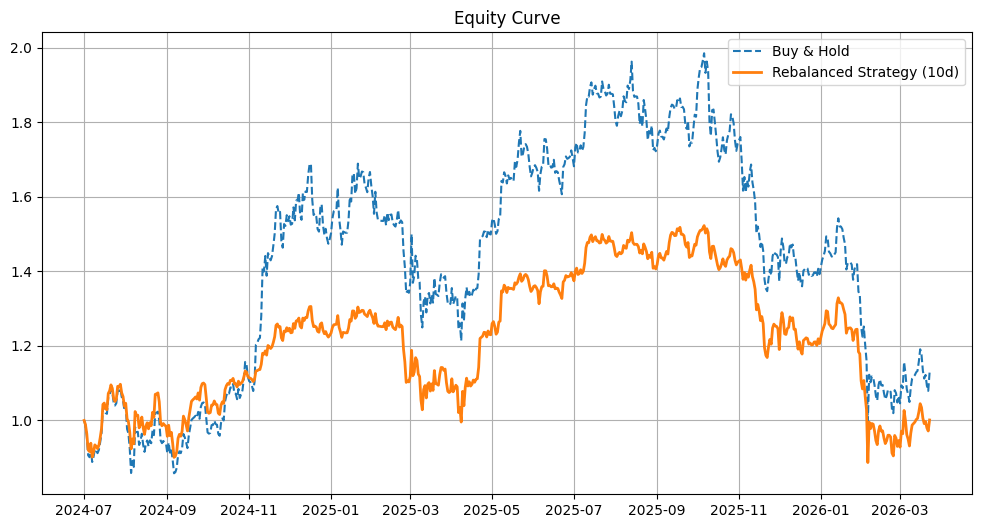

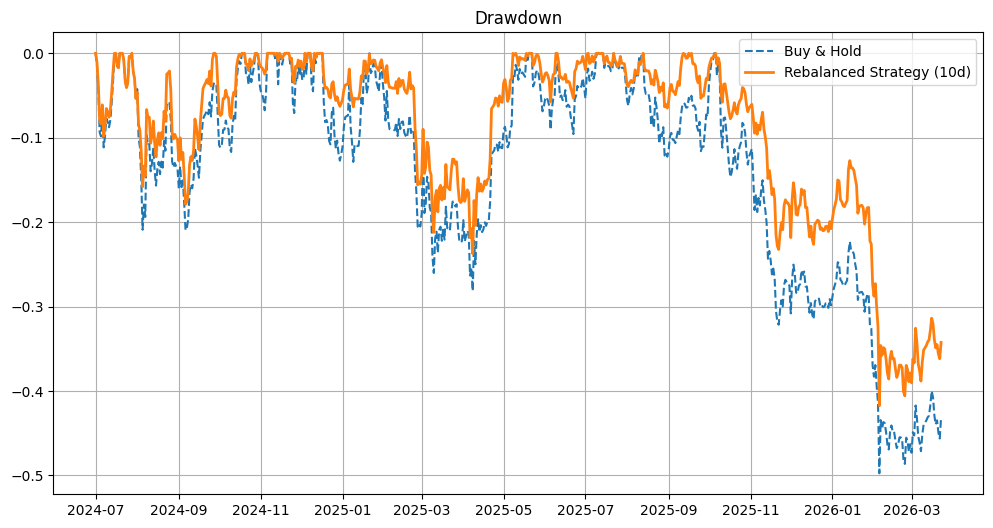

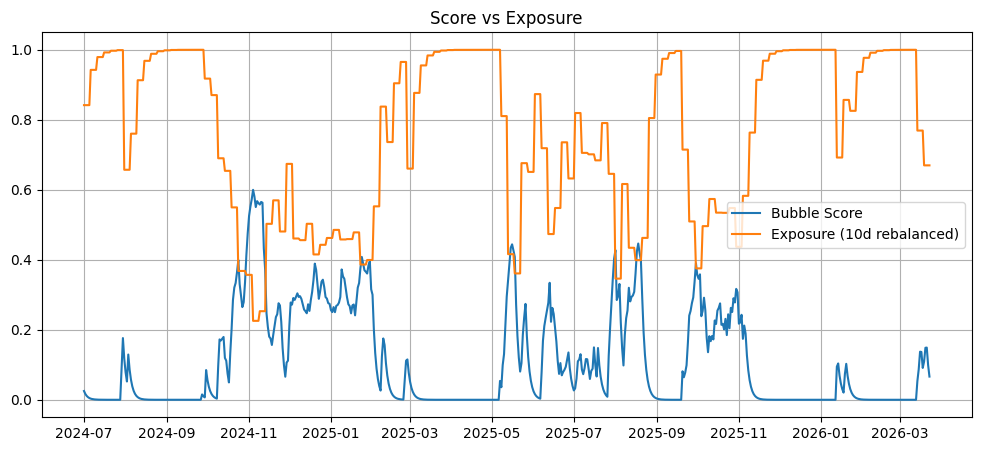

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# SIMPLE STRATEGY WITH PERIODIC REBALANCING
# ============================================================

df = df.copy()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

PRICE_COL = 'BCP'
SCORE_COL = 'bubble_score'

fee = 0.001
REBALANCE_DAYS = 5

# ------------------------------------------------------------
# DATA PREPARATION
# ------------------------------------------------------------

df[PRICE_COL] = df[PRICE_COL].astype(float)
df[SCORE_COL] = df[SCORE_COL].ffill().fillna(0).clip(0, 1)

df['ret'] = df[PRICE_COL].pct_change().fillna(0)

# ============================================================
# STRATEGY: PERIODIC REBALANCING
# ============================================================

# Buy & Hold
df['position_bh'] = 1.0

# Compute target exposure
MAX_EXPOSURE = 1
ALPHA = 0.5

df['target_position'] = MAX_EXPOSURE * (1 - df[SCORE_COL]**ALPHA)

# Initialize actual position
positions = []
current_position = df['target_position'].iloc[0]

for i in range(len(df)):

    # rebalance every N days
    if i % REBALANCE_DAYS == 0:
        current_position = df['target_position'].iloc[i]

    positions.append(current_position)

df['position_strategy'] = positions

# ============================================================
# RETURNS
# ============================================================

def apply_strategy(df, position_col, ret_col='ret', fee=0.001):
    out = df.copy()

    trade_col = f'trade_{position_col}'
    ret_strategy_col = f'ret_{position_col}'
    equity_col = f'equity_{position_col}'

    # trades only occur at rebalancing points now
    out[trade_col] = out[position_col].diff().abs().fillna(0)

    out[ret_strategy_col] = (
        out[position_col].shift(1).fillna(out[position_col]) * out[ret_col]
    )

    out[ret_strategy_col] -= out[trade_col] * fee

    out[equity_col] = (1 + out[ret_strategy_col]).cumprod()

    return out, ret_strategy_col, equity_col, trade_col


df, ret_bh, equity_bh, trade_bh = apply_strategy(df, 'position_bh', fee=fee)
df, ret_strat, equity_strat, trade_strat = apply_strategy(df, 'position_strategy', fee=fee)

# ============================================================
# METRICS
# ============================================================

def compute_drawdown(equity):
    peak = equity.cummax()
    return (equity - peak) / peak


def compute_metrics(df, ret_col, equity_col, trade_col, position_col, name):
    ret = df[ret_col]
    equity = df[equity_col]

    total_return = equity.iloc[-1] / equity.iloc[0] - 1
    ann_return = (1 + total_return) ** (365 / len(df)) - 1
    ann_vol = ret.std() * np.sqrt(365)
    sharpe = ann_return / ann_vol if ann_vol != 0 else np.nan

    dd = compute_drawdown(equity)
    max_dd = dd.min()
    calmar = ann_return / abs(max_dd) if max_dd != 0 else np.nan

    return {
        'Strategy': name,
        'Final Value': equity.iloc[-1],
        'Total Return': total_return,
        'Annual Return': ann_return,
        'Annual Volatility': ann_vol,
        'Sharpe Ratio': sharpe,
        'Max Drawdown': max_dd,
        'Calmar Ratio': calmar,
        'Average Exposure': df[position_col].mean(),
        'Turnover': df[trade_col].sum()
    }


metrics = pd.DataFrame([
    compute_metrics(df, ret_bh, equity_bh, trade_bh, 'position_bh', 'Buy & Hold'),
    compute_metrics(df, ret_strat, equity_strat, trade_strat, 'position_strategy', 'Rebalanced Strategy (10d)')
])

display(metrics)

# ============================================================
# DRAWDOWNS
# ============================================================

df['dd_bh'] = compute_drawdown(df[equity_bh])
df['dd_strategy'] = compute_drawdown(df[equity_strat])

# ============================================================
# PLOTS
# ============================================================

# Equity
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df[equity_bh], label='Buy & Hold', linestyle='--')
plt.plot(df['Date'], df[equity_strat], label='Rebalanced Strategy (10d)', linewidth=2)
plt.title('Equity Curve')
plt.legend()
plt.grid(True)
plt.show()

# Drawdown
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['dd_bh'], label='Buy & Hold', linestyle='--')
plt.plot(df['Date'], df['dd_strategy'], label='Rebalanced Strategy (10d)', linewidth=2)
plt.title('Drawdown')
plt.legend()
plt.grid(True)
plt.show()

# Exposure
plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df[SCORE_COL], label='Bubble Score')
plt.plot(df['Date'], df['position_strategy'], label='Exposure (10d rebalanced)')
plt.title('Score vs Exposure')
plt.legend()
plt.grid(True)
plt.show()

### Strategia con FGI

,Strategy,Final Value,Total Return,Annual Return,Annual Volatility,Sharpe Ratio,Max Drawdown,Calmar Ratio,Average Exposure,Turnover
0,Buy & Hold,1.128284,0.128284,0.072431,0.479752,0.150976,-0.497388,0.145622,1.000000,0.000000
1,80% Buy & Hold,1.136722,0.136722,0.077071,0.383802,0.200808,-0.419264,0.183824,0.800000,0.000000
2,FGI Strategy,1.040626,0.040626,0.023340,0.287012,0.081320,-0.366601,0.063666,0.521452,5.974299


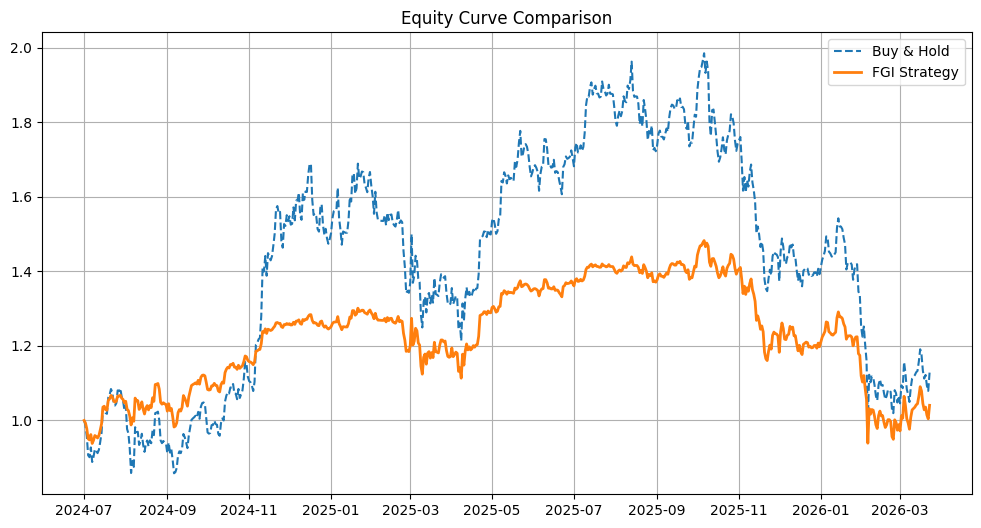

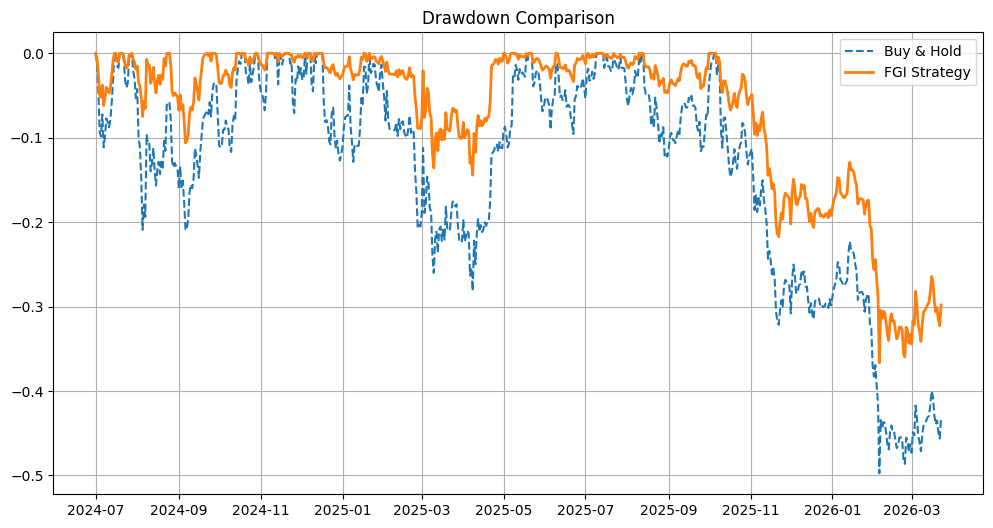

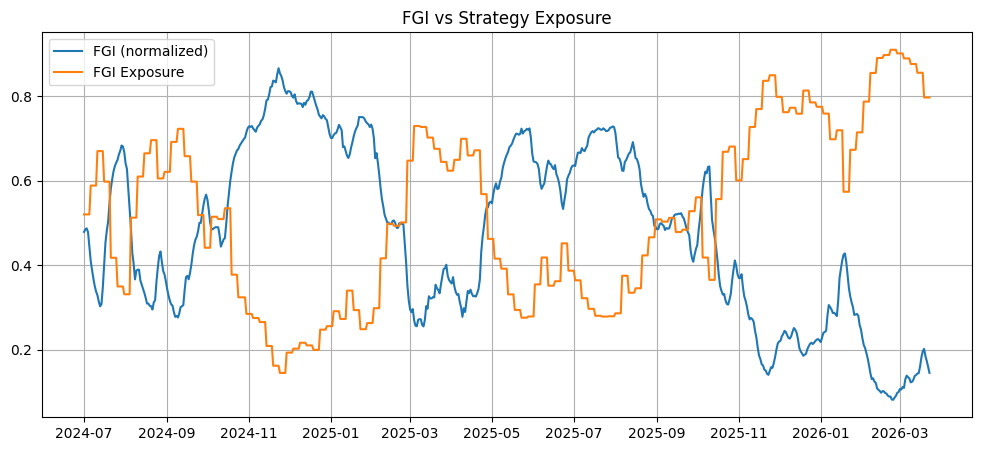

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# FGI-BASED STRATEGY (ANALOGOUS TO BUBBLE SCORE)
# ============================================================

df = df.copy()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

PRICE_COL = 'BCP'
FGI_COL = 'FGI'

fee = 0.001
REBALANCE_DAYS = 5

MAX_EXPOSURE = 1
ALPHA = 1   # same nonlinear mapping used before

# ------------------------------------------------------------
# DATA PREPARATION
# ------------------------------------------------------------

df[PRICE_COL] = df[PRICE_COL].astype(float)
df[FGI_COL] = df[FGI_COL].ffill().fillna(50)

df['ret'] = df[PRICE_COL].pct_change().fillna(0)

# ============================================================
# NORMALIZE FGI
# ============================================================

df['fgi_norm'] = (df[FGI_COL] / 100).clip(0, 1)

# ============================================================
# TARGET EXPOSURE (SAME FORMULA)
# ============================================================

df['target_position_fgi'] = MAX_EXPOSURE * (1 - df['fgi_norm']**ALPHA)

# ============================================================
# PERIODIC REBALANCING
# ============================================================

positions = []
current_position = df['target_position_fgi'].iloc[0]

for i in range(len(df)):

    if i % REBALANCE_DAYS == 0:
        current_position = df['target_position_fgi'].iloc[i]

    positions.append(current_position)

df['position_fgi'] = positions

# ============================================================
# RETURNS
# ============================================================

def apply_strategy(df, position_col, ret_col='ret', fee=0.001):
    out = df.copy()

    trade_col = f'trade_{position_col}'
    ret_strategy_col = f'ret_{position_col}'
    equity_col = f'equity_{position_col}'

    out[trade_col] = out[position_col].diff().abs().fillna(0)

    out[ret_strategy_col] = (
        out[position_col].shift(1).fillna(out[position_col]) * out[ret_col]
    )

    out[ret_strategy_col] -= out[trade_col] * fee

    out[equity_col] = (1 + out[ret_strategy_col]).cumprod()

    return out, ret_strategy_col, equity_col, trade_col


# Buy & Hold
df['position_bh'] = 1.0
df, ret_bh, equity_bh, trade_bh = apply_strategy(df, 'position_bh', fee=fee)

# 80% Buy & Hold (fair comparison)
df['position_80_bh'] = 0.80
df, ret_80_bh, equity_80_bh, trade_80_bh = apply_strategy(df, 'position_80_bh', fee=fee)

# FGI strategy
df, ret_fgi, equity_fgi, trade_fgi = apply_strategy(df, 'position_fgi', fee=fee)

# ============================================================
# METRICS
# ============================================================

def compute_drawdown(equity):
    peak = equity.cummax()
    return (equity - peak) / peak


def compute_metrics(df, ret_col, equity_col, trade_col, position_col, name):
    ret = df[ret_col]
    equity = df[equity_col]

    total_return = equity.iloc[-1] / equity.iloc[0] - 1
    ann_return = (1 + total_return) ** (365 / len(df)) - 1
    ann_vol = ret.std() * np.sqrt(365)
    sharpe = ann_return / ann_vol if ann_vol != 0 else np.nan

    dd = compute_drawdown(equity)
    max_dd = dd.min()
    calmar = ann_return / abs(max_dd) if max_dd != 0 else np.nan

    return {
        'Strategy': name,
        'Final Value': equity.iloc[-1],
        'Total Return': total_return,
        'Annual Return': ann_return,
        'Annual Volatility': ann_vol,
        'Sharpe Ratio': sharpe,
        'Max Drawdown': max_dd,
        'Calmar Ratio': calmar,
        'Average Exposure': df[position_col].mean(),
        'Turnover': df[trade_col].sum()
    }


metrics = pd.DataFrame([
    compute_metrics(df, ret_bh, equity_bh, trade_bh, 'position_bh', 'Buy & Hold'),
    compute_metrics(df, ret_80_bh, equity_80_bh, trade_80_bh, 'position_80_bh', '80% Buy & Hold'),
    compute_metrics(df, ret_fgi, equity_fgi, trade_fgi, 'position_fgi', 'FGI Strategy')
])

display(metrics)

# ============================================================
# DRAWDOWNS
# ============================================================

df['dd_bh'] = compute_drawdown(df[equity_bh])
df['dd_80_bh'] = compute_drawdown(df[equity_80_bh])
df['dd_fgi'] = compute_drawdown(df[equity_fgi])

# ============================================================
# PLOTS
# ============================================================

# Equity comparison
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df[equity_bh], label='Buy & Hold', linestyle='--')
#plt.plot(df['Date'], df[equity_80_bh], label='80% Buy & Hold')
plt.plot(df['Date'], df[equity_fgi], label='FGI Strategy', linewidth=2)
plt.title('Equity Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()

# Drawdown comparison
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['dd_bh'], label='Buy & Hold', linestyle='--')
#plt.plot(df['Date'], df['dd_80_bh'], label='80% Buy & Hold')
plt.plot(df['Date'], df['dd_fgi'], label='FGI Strategy', linewidth=2)
plt.title('Drawdown Comparison')
plt.legend()
plt.grid(True)
plt.show()

# FGI vs exposure
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['fgi_norm'], label='FGI (normalized)')
plt.plot(df['Date'], df['position_fgi'], label='FGI Exposure')
plt.title('FGI vs Strategy Exposure')
plt.legend()
plt.grid(True)
plt.show()

### Strategia LPPLS*FGI con fear exit

,Strategy,Final Value,Total Return,Annual Return,Annual Volatility,Sharpe Ratio,Max Drawdown,Calmar Ratio,Average Exposure,Turnover
0,Buy & Hold,1.128284,0.128284,0.072431,0.479752,0.150976,-0.497388,0.145622,1.000000,0.000000
1,80% Buy & Hold,1.136722,0.136722,0.077071,0.383802,0.200808,-0.419264,0.183824,0.800000,0.000000
2,LPPLS × FGI + Fear Exit,1.049340,0.049340,0.028296,0.199949,0.141515,-0.198562,0.142504,0.432029,7.457534


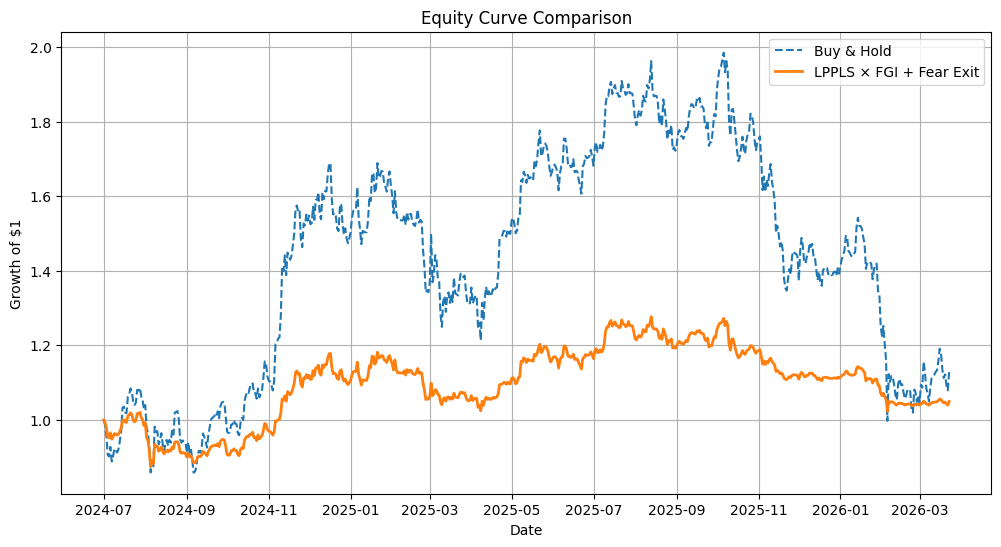

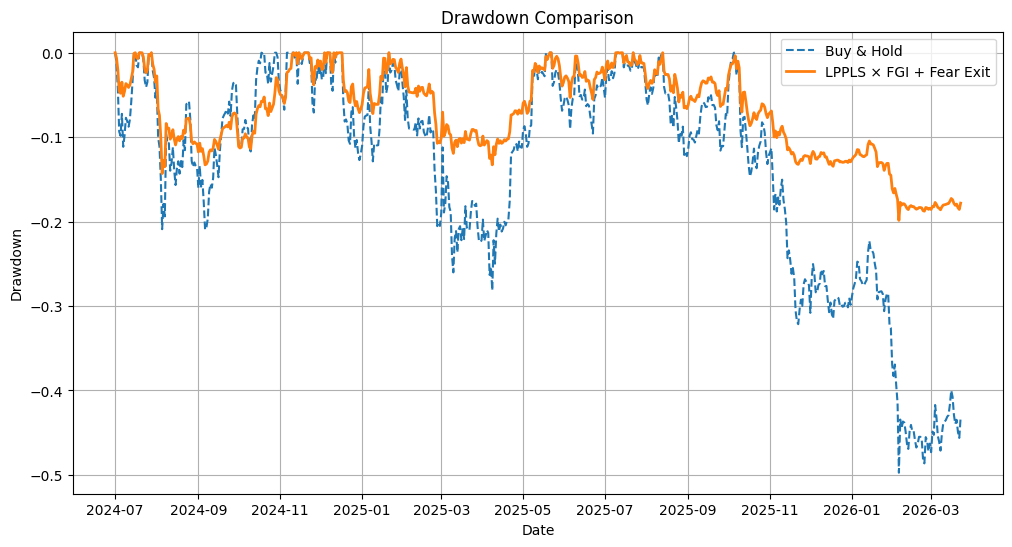

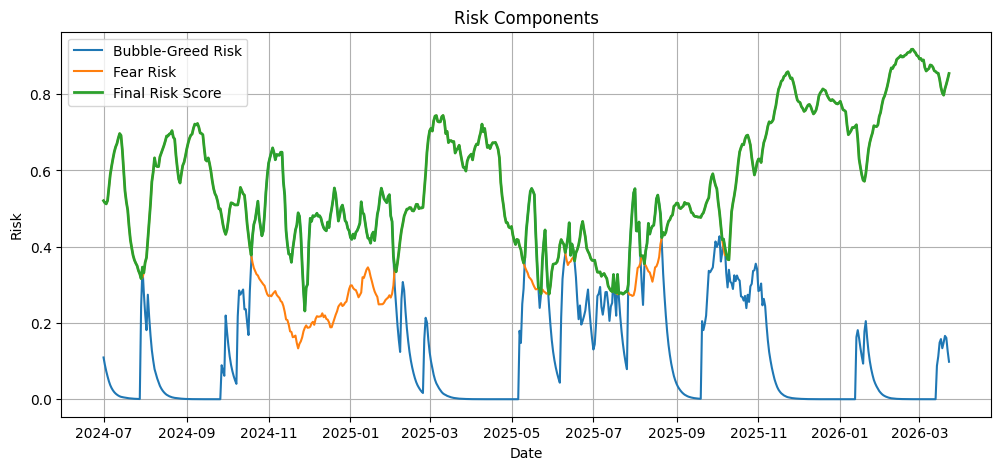

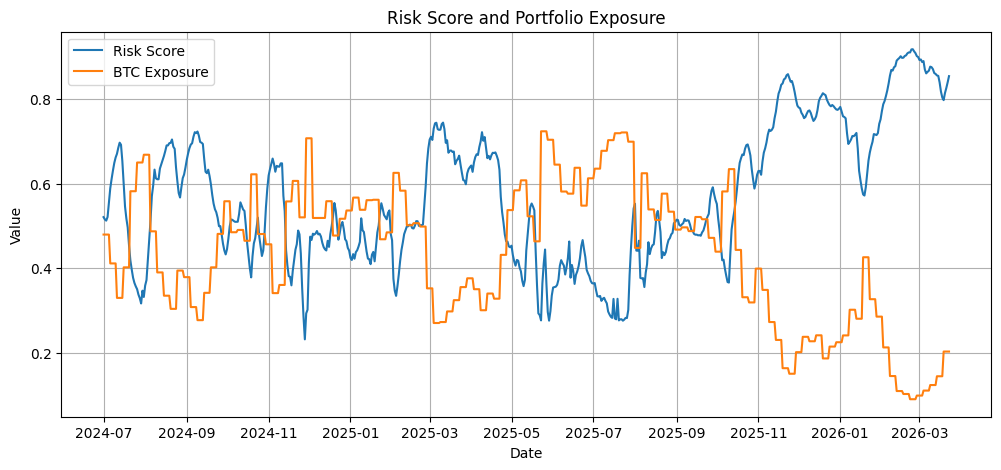

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# LPPLS + FGI STRATEGY WITH FEAR EXIT
# ============================================================

df = df.copy()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

PRICE_COL = 'BCP'
BUBBLE_COL = 'bubble_score'
FGI_COL = 'FGI'

fee = 0.001
REBALANCE_DAYS = 5
MAX_EXPOSURE = 1
ALPHA = 1

# ------------------------------------------------------------
# DATA PREPARATION
# ------------------------------------------------------------

df[PRICE_COL] = df[PRICE_COL].astype(float)
df[BUBBLE_COL] = df[BUBBLE_COL].ffill().fillna(0).clip(0, 1)
df[FGI_COL] = df[FGI_COL].ffill().fillna(50)

df['ret'] = df[PRICE_COL].pct_change().fillna(0)

# ------------------------------------------------------------
# SIGNALS
# ------------------------------------------------------------

df['lppls_score'] = df[BUBBLE_COL]
df['fgi_norm'] = (df[FGI_COL] / 100).clip(0, 1)

# Greed/bubble risk: high when both LPPLS and FGI are high
df['bubble_greed_risk'] = (df['lppls_score'] * df['fgi_norm'])**(0.5)

# Fear risk: high when FGI is low
df['fear_risk'] = 1 - df['fgi_norm']

# Final risk score: risk is high either in euphoric bubble or panic/fear
df['risk_score'] = np.maximum(df['bubble_greed_risk'], df['fear_risk']).clip(0, 1)

# ------------------------------------------------------------
# TARGET EXPOSURE
# ------------------------------------------------------------

df['target_position_risk'] = MAX_EXPOSURE * (1 - df['risk_score']**ALPHA)

# ------------------------------------------------------------
# PERIODIC REBALANCING
# ------------------------------------------------------------

positions = []
current_position = df['target_position_risk'].iloc[0]

for i in range(len(df)):
    if i % REBALANCE_DAYS == 0:
        current_position = df['target_position_risk'].iloc[i]
    positions.append(current_position)

df['position_risk'] = positions

# ------------------------------------------------------------
# APPLY STRATEGY
# ------------------------------------------------------------

def apply_strategy(df, position_col, ret_col='ret', fee=0.001):
    out = df.copy()

    trade_col = f'trade_{position_col}'
    ret_strategy_col = f'ret_{position_col}'
    equity_col = f'equity_{position_col}'

    out[trade_col] = out[position_col].diff().abs().fillna(0)

    out[ret_strategy_col] = (
        out[position_col].shift(1).fillna(out[position_col]) * out[ret_col]
    )

    out[ret_strategy_col] -= out[trade_col] * fee
    out[equity_col] = (1 + out[ret_strategy_col]).cumprod()

    return out, ret_strategy_col, equity_col, trade_col

# ------------------------------------------------------------
# BENCHMARKS
# ------------------------------------------------------------

df['position_bh'] = 1.0
df['position_80_bh'] = 0.80

df, ret_bh, equity_bh, trade_bh = apply_strategy(df, 'position_bh', fee=fee)
df, ret_80_bh, equity_80_bh, trade_80_bh = apply_strategy(df, 'position_80_bh', fee=fee)
df, ret_risk, equity_risk, trade_risk = apply_strategy(df, 'position_risk', fee=fee)

# ------------------------------------------------------------
# METRICS
# ------------------------------------------------------------

def compute_drawdown(equity):
    peak = equity.cummax()
    return (equity - peak) / peak


def compute_metrics(df, ret_col, equity_col, trade_col, position_col, name):
    ret = df[ret_col]
    equity = df[equity_col]

    total_return = equity.iloc[-1] / equity.iloc[0] - 1
    ann_return = (1 + total_return) ** (365 / len(df)) - 1
    ann_vol = ret.std() * np.sqrt(365)
    sharpe = ann_return / ann_vol if ann_vol != 0 else np.nan

    dd = compute_drawdown(equity)
    max_dd = dd.min()
    calmar = ann_return / abs(max_dd) if max_dd != 0 else np.nan

    return {
        'Strategy': name,
        'Final Value': equity.iloc[-1],
        'Total Return': total_return,
        'Annual Return': ann_return,
        'Annual Volatility': ann_vol,
        'Sharpe Ratio': sharpe,
        'Max Drawdown': max_dd,
        'Calmar Ratio': calmar,
        'Average Exposure': df[position_col].mean(),
        'Turnover': df[trade_col].sum()
    }


metrics = pd.DataFrame([
    compute_metrics(df, ret_bh, equity_bh, trade_bh, 'position_bh', 'Buy & Hold'),
    compute_metrics(df, ret_80_bh, equity_80_bh, trade_80_bh, 'position_80_bh', '80% Buy & Hold'),
    compute_metrics(df, ret_risk, equity_risk, trade_risk, 'position_risk', 'LPPLS × FGI + Fear Exit')
])

display(metrics)

# ------------------------------------------------------------
# DRAWDOWNS
# ------------------------------------------------------------

df['dd_bh'] = compute_drawdown(df[equity_bh])
df['dd_80_bh'] = compute_drawdown(df[equity_80_bh])
df['dd_risk'] = compute_drawdown(df[equity_risk])

# ------------------------------------------------------------
# PLOTS
# ------------------------------------------------------------

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df[equity_bh], label='Buy & Hold', linestyle='--')
#plt.plot(df['Date'], df[equity_80_bh], label='80% Buy & Hold')
plt.plot(df['Date'], df[equity_risk], label='LPPLS × FGI + Fear Exit', linewidth=2)
plt.title('Equity Curve Comparison')
plt.xlabel('Date')
plt.ylabel('Growth of $1')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['dd_bh'], label='Buy & Hold', linestyle='--')
#plt.plot(df['Date'], df['dd_80_bh'], label='80% Buy & Hold')
plt.plot(df['Date'], df['dd_risk'], label='LPPLS × FGI + Fear Exit', linewidth=2)
plt.title('Drawdown Comparison')
plt.xlabel('Date')
plt.ylabel('Drawdown')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['bubble_greed_risk'], label='Bubble-Greed Risk')
plt.plot(df['Date'], df['fear_risk'], label='Fear Risk')
plt.plot(df['Date'], df['risk_score'], label='Final Risk Score', linewidth=2)
plt.title('Risk Components')
plt.xlabel('Date')
plt.ylabel('Risk')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['risk_score'], label='Risk Score')
plt.plot(df['Date'], df['position_risk'], label='BTC Exposure')
plt.title('Risk Score and Portfolio Exposure')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

### Stesso con composizione additiva LBS e FGI

,Strategy,Final Value,Total Return,Annual Return,Annual Volatility,Sharpe Ratio,Max Drawdown,Calmar Ratio,Average Exposure,Turnover
0,Buy & Hold,1.128284,0.128284,0.072431,0.479752,0.150976,-0.497388,0.145622,1.000000,0.00000
1,80% Buy & Hold,1.136722,0.136722,0.077071,0.383802,0.200808,-0.419264,0.183824,0.800000,0.00000
2,LPPLS × FGI + Fear Exit,1.055126,0.055126,0.031577,0.191876,0.164572,-0.195719,0.161339,0.413678,6.61824


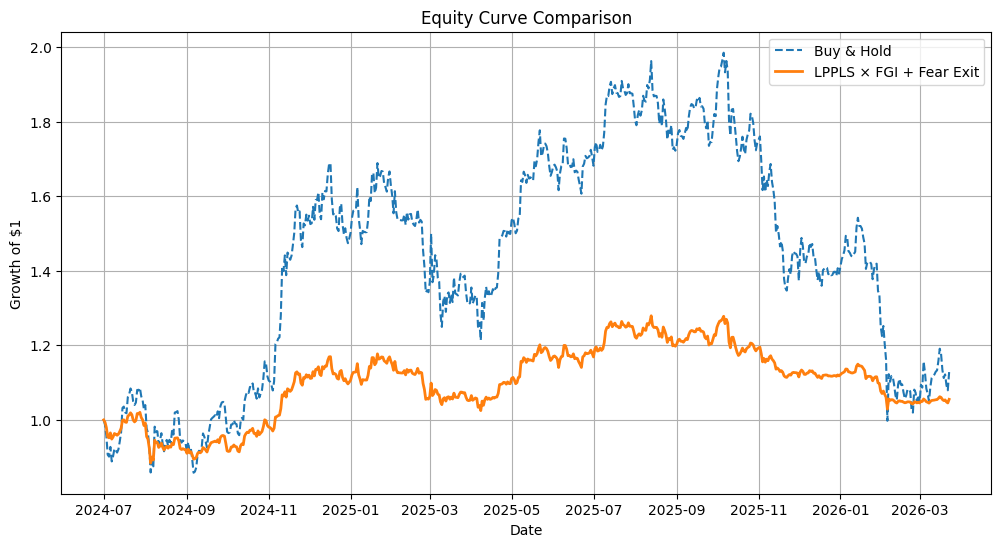

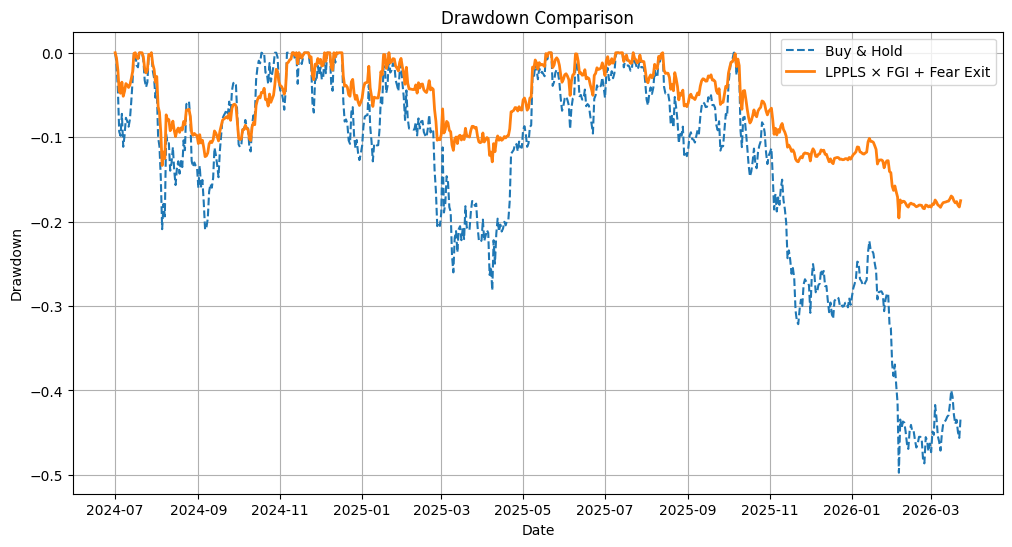

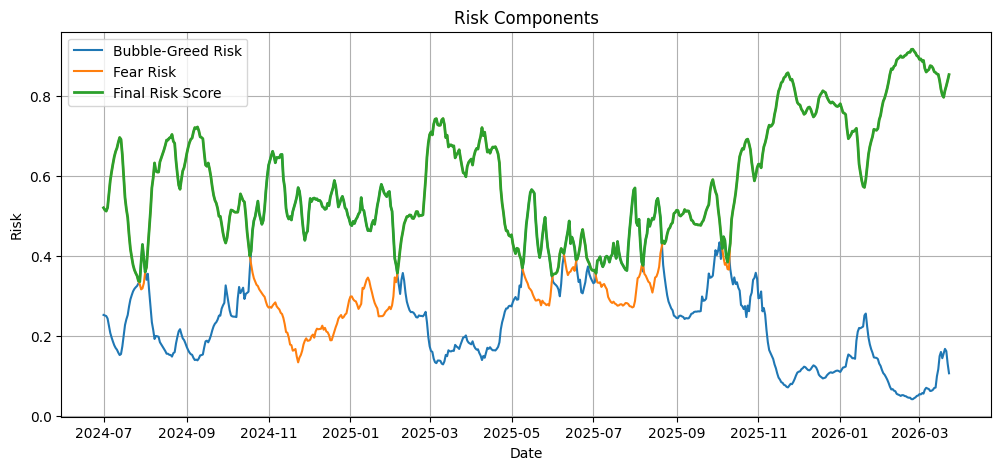

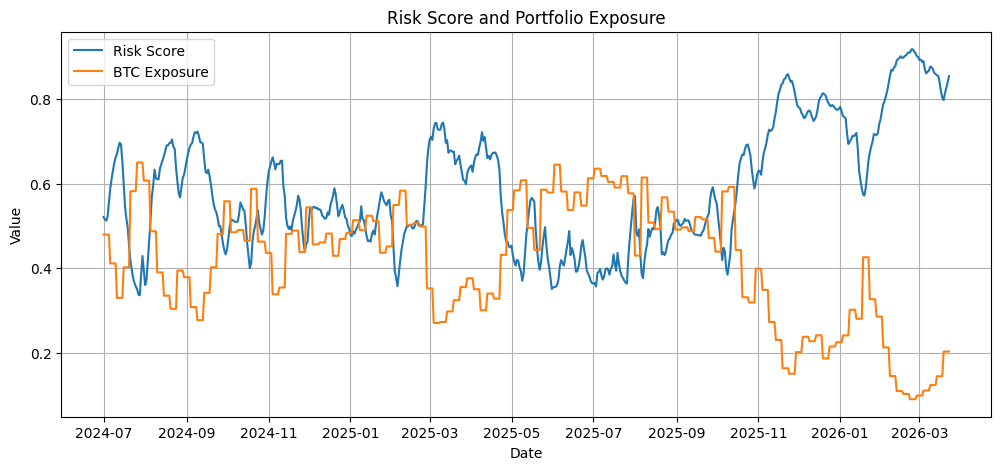

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# LPPLS + FGI STRATEGY WITH FEAR EXIT
# ============================================================

df = df.copy()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

PRICE_COL = 'BCP'
BUBBLE_COL = 'bubble_score'
FGI_COL = 'FGI'

fee = 0.001
REBALANCE_DAYS = 5
MAX_EXPOSURE = 1
ALPHA = 1

# ------------------------------------------------------------
# DATA PREPARATION
# ------------------------------------------------------------

df[PRICE_COL] = df[PRICE_COL].astype(float)
df[BUBBLE_COL] = df[BUBBLE_COL].ffill().fillna(0).clip(0, 1)
df[FGI_COL] = df[FGI_COL].ffill().fillna(50)

df['ret'] = df[PRICE_COL].pct_change().fillna(0)

# ------------------------------------------------------------
# SIGNALS
# ------------------------------------------------------------

df['lppls_score'] = df[BUBBLE_COL]
df['fgi_norm'] = (df[FGI_COL] / 100).clip(0, 1)

# Greed/bubble risk: high when both LPPLS and FGI are high
df['bubble_greed_risk'] = 0.5*df['lppls_score'] + 0.5*df['fgi_norm']

# Fear risk: high when FGI is low
df['fear_risk'] = 1 - df['fgi_norm']

# Final risk score: risk is high either in euphoric bubble or panic/fear
df['risk_score'] = np.maximum(df['bubble_greed_risk'], df['fear_risk']).clip(0, 1)

# ------------------------------------------------------------
# TARGET EXPOSURE
# ------------------------------------------------------------

df['target_position_risk'] = MAX_EXPOSURE * (1 - df['risk_score']**ALPHA)

# ------------------------------------------------------------
# PERIODIC REBALANCING
# ------------------------------------------------------------

positions = []
current_position = df['target_position_risk'].iloc[0]

for i in range(len(df)):
    if i % REBALANCE_DAYS == 0:
        current_position = df['target_position_risk'].iloc[i]
    positions.append(current_position)

df['position_risk'] = positions

# ------------------------------------------------------------
# APPLY STRATEGY
# ------------------------------------------------------------

def apply_strategy(df, position_col, ret_col='ret', fee=0.001):
    out = df.copy()

    trade_col = f'trade_{position_col}'
    ret_strategy_col = f'ret_{position_col}'
    equity_col = f'equity_{position_col}'

    out[trade_col] = out[position_col].diff().abs().fillna(0)

    out[ret_strategy_col] = (
        out[position_col].shift(1).fillna(out[position_col]) * out[ret_col]
    )

    out[ret_strategy_col] -= out[trade_col] * fee
    out[equity_col] = (1 + out[ret_strategy_col]).cumprod()

    return out, ret_strategy_col, equity_col, trade_col

# ------------------------------------------------------------
# BENCHMARKS
# ------------------------------------------------------------

df['position_bh'] = 1.0
df['position_80_bh'] = 0.80

df, ret_bh, equity_bh, trade_bh = apply_strategy(df, 'position_bh', fee=fee)
df, ret_80_bh, equity_80_bh, trade_80_bh = apply_strategy(df, 'position_80_bh', fee=fee)
df, ret_risk, equity_risk, trade_risk = apply_strategy(df, 'position_risk', fee=fee)

# ------------------------------------------------------------
# METRICS
# ------------------------------------------------------------

def compute_drawdown(equity):
    peak = equity.cummax()
    return (equity - peak) / peak


def compute_metrics(df, ret_col, equity_col, trade_col, position_col, name):
    ret = df[ret_col]
    equity = df[equity_col]

    total_return = equity.iloc[-1] / equity.iloc[0] - 1
    ann_return = (1 + total_return) ** (365 / len(df)) - 1
    ann_vol = ret.std() * np.sqrt(365)
    sharpe = ann_return / ann_vol if ann_vol != 0 else np.nan

    dd = compute_drawdown(equity)
    max_dd = dd.min()
    calmar = ann_return / abs(max_dd) if max_dd != 0 else np.nan

    return {
        'Strategy': name,
        'Final Value': equity.iloc[-1],
        'Total Return': total_return,
        'Annual Return': ann_return,
        'Annual Volatility': ann_vol,
        'Sharpe Ratio': sharpe,
        'Max Drawdown': max_dd,
        'Calmar Ratio': calmar,
        'Average Exposure': df[position_col].mean(),
        'Turnover': df[trade_col].sum()
    }


metrics = pd.DataFrame([
    compute_metrics(df, ret_bh, equity_bh, trade_bh, 'position_bh', 'Buy & Hold'),
    compute_metrics(df, ret_80_bh, equity_80_bh, trade_80_bh, 'position_80_bh', '80% Buy & Hold'),
    compute_metrics(df, ret_risk, equity_risk, trade_risk, 'position_risk', 'LPPLS × FGI + Fear Exit')
])

display(metrics)

# ------------------------------------------------------------
# DRAWDOWNS
# ------------------------------------------------------------

df['dd_bh'] = compute_drawdown(df[equity_bh])
df['dd_80_bh'] = compute_drawdown(df[equity_80_bh])
df['dd_risk'] = compute_drawdown(df[equity_risk])

# ------------------------------------------------------------
# PLOTS
# ------------------------------------------------------------

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df[equity_bh], label='Buy & Hold', linestyle='--')
#plt.plot(df['Date'], df[equity_80_bh], label='80% Buy & Hold')
plt.plot(df['Date'], df[equity_risk], label='LPPLS × FGI + Fear Exit', linewidth=2)
plt.title('Equity Curve Comparison')
plt.xlabel('Date')
plt.ylabel('Growth of $1')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['dd_bh'], label='Buy & Hold', linestyle='--')
#plt.plot(df['Date'], df['dd_80_bh'], label='80% Buy & Hold')
plt.plot(df['Date'], df['dd_risk'], label='LPPLS × FGI + Fear Exit', linewidth=2)
plt.title('Drawdown Comparison')
plt.xlabel('Date')
plt.ylabel('Drawdown')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['bubble_greed_risk'], label='Bubble-Greed Risk')
plt.plot(df['Date'], df['fear_risk'], label='Fear Risk')
plt.plot(df['Date'], df['risk_score'], label='Final Risk Score', linewidth=2)
plt.title('Risk Components')
plt.xlabel('Date')
plt.ylabel('Risk')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['risk_score'], label='Risk Score')
plt.plot(df['Date'], df['position_risk'], label='BTC Exposure')
plt.title('Risk Score and Portfolio Exposure')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

## Strategies su DatasetC

In [7]:
start_date = pd.to_datetime('2025-01-01')
dfC = df[df['Date'] >= start_date].reset_index(drop=True)
print(df.head())
print(df.tail())

        Date           BCP   FGI  log_price  t  lppls_score  lppls_r2_score  \
0 2022-06-22  19987.029297  11.0   9.902839  0          0.0             0.0   
1 2022-06-23  21085.876953  11.0   9.956359  1          0.0             0.0   
2 2022-06-24  21231.656250  11.0   9.963249  2          0.0             0.0   
3 2022-06-25  21502.337891  14.0   9.975917  3          0.0             0.0   
4 2022-06-26  21027.294922  14.0   9.953577  4          0.0             0.0   

   lppls_urgency  lppls_tc_median  lppls_days_to_tc  ...  \
0            0.0              NaN               NaN  ...   
1            0.0              NaN               NaN  ...   
2            0.0              NaN               NaN  ...   
3            0.0              NaN               NaN  ...   
4            0.0              NaN               NaN  ...   

   lppls_score_tc_smooth_smooth  lppls_urgency_smooth_tc_smooth  \
0                           0.0                             0.0   
1                           0.

In [9]:
df = dfC

### Strategia con LPPLS bubble score

,Strategy,Final Value,Total Return,Annual Return,Annual Volatility,Sharpe Ratio,Max Drawdown,Calmar Ratio,Average Exposure,Turnover
0,Buy & Hold,0.751060,-0.248940,-0.208445,0.459956,-0.453184,-0.497388,-0.419078,1.000000,0.000000
1,Rebalanced Strategy (10d),0.839106,-0.160894,-0.133453,0.392290,-0.340189,-0.419701,-0.317971,0.777722,8.363379


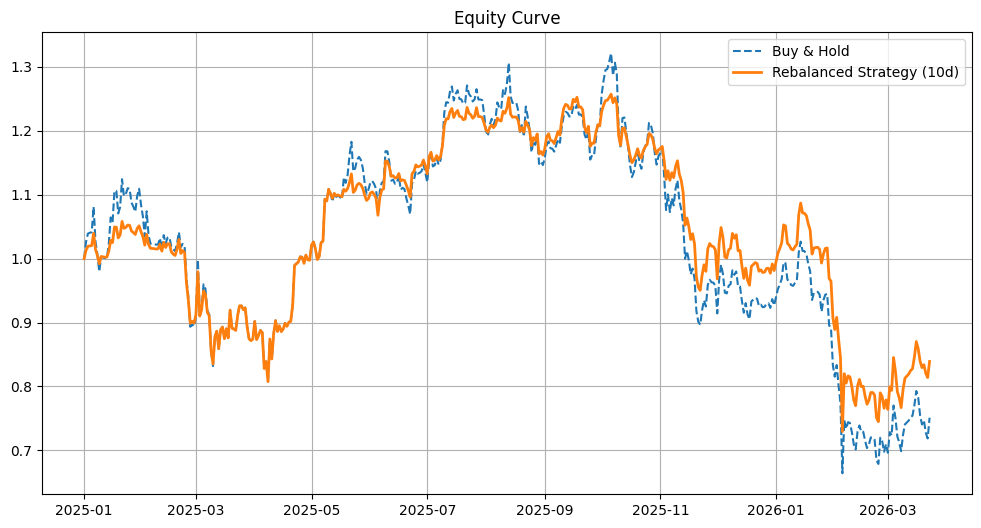

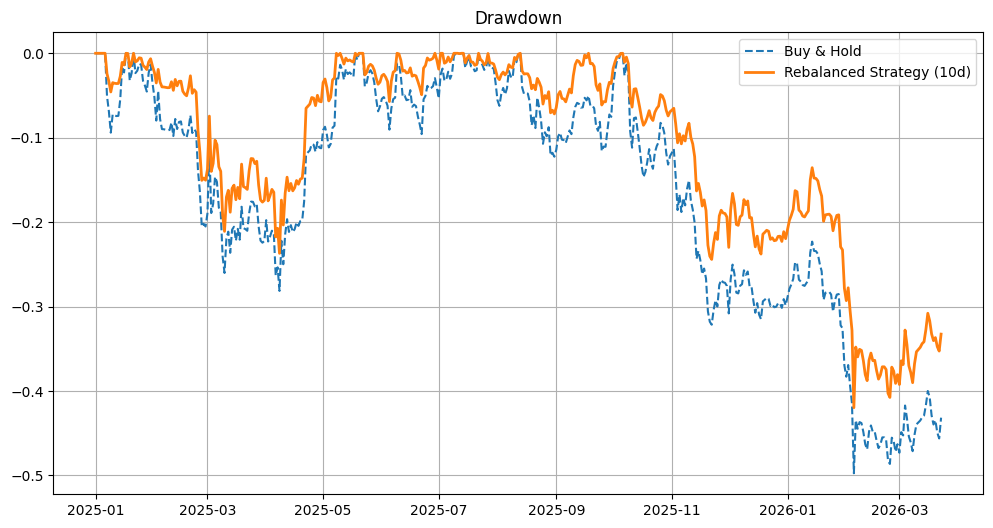

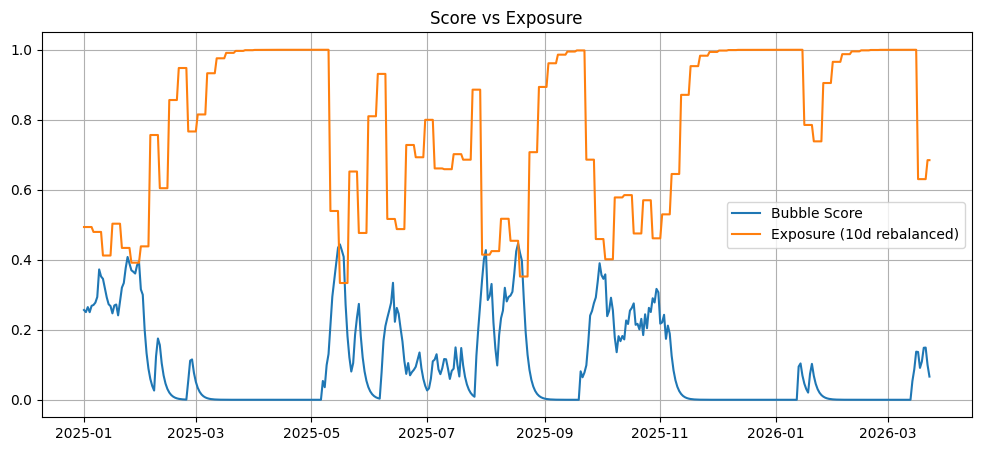

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# SIMPLE STRATEGY WITH PERIODIC REBALANCING
# ============================================================

df = df.copy()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

PRICE_COL = 'BCP'
SCORE_COL = 'bubble_score'

fee = 0.001
REBALANCE_DAYS = 5

# ------------------------------------------------------------
# DATA PREPARATION
# ------------------------------------------------------------

df[PRICE_COL] = df[PRICE_COL].astype(float)
df[SCORE_COL] = df[SCORE_COL].ffill().fillna(0).clip(0, 1)

df['ret'] = df[PRICE_COL].pct_change().fillna(0)

# ============================================================
# STRATEGY: PERIODIC REBALANCING
# ============================================================

# Buy & Hold
df['position_bh'] = 1.0

# Compute target exposure
MAX_EXPOSURE = 1
ALPHA = 0.5

df['target_position'] = MAX_EXPOSURE * (1 - df[SCORE_COL]**ALPHA)

# Initialize actual position
positions = []
current_position = df['target_position'].iloc[0]

for i in range(len(df)):

    # rebalance every N days
    if i % REBALANCE_DAYS == 0:
        current_position = df['target_position'].iloc[i]

    positions.append(current_position)

df['position_strategy'] = positions

# ============================================================
# RETURNS
# ============================================================

def apply_strategy(df, position_col, ret_col='ret', fee=0.001):
    out = df.copy()

    trade_col = f'trade_{position_col}'
    ret_strategy_col = f'ret_{position_col}'
    equity_col = f'equity_{position_col}'

    # trades only occur at rebalancing points now
    out[trade_col] = out[position_col].diff().abs().fillna(0)

    out[ret_strategy_col] = (
        out[position_col].shift(1).fillna(out[position_col]) * out[ret_col]
    )

    out[ret_strategy_col] -= out[trade_col] * fee

    out[equity_col] = (1 + out[ret_strategy_col]).cumprod()

    return out, ret_strategy_col, equity_col, trade_col


df, ret_bh, equity_bh, trade_bh = apply_strategy(df, 'position_bh', fee=fee)
df, ret_strat, equity_strat, trade_strat = apply_strategy(df, 'position_strategy', fee=fee)

# ============================================================
# METRICS
# ============================================================

def compute_drawdown(equity):
    peak = equity.cummax()
    return (equity - peak) / peak


def compute_metrics(df, ret_col, equity_col, trade_col, position_col, name):
    ret = df[ret_col]
    equity = df[equity_col]

    total_return = equity.iloc[-1] / equity.iloc[0] - 1
    ann_return = (1 + total_return) ** (365 / len(df)) - 1
    ann_vol = ret.std() * np.sqrt(365)
    sharpe = ann_return / ann_vol if ann_vol != 0 else np.nan

    dd = compute_drawdown(equity)
    max_dd = dd.min()
    calmar = ann_return / abs(max_dd) if max_dd != 0 else np.nan

    return {
        'Strategy': name,
        'Final Value': equity.iloc[-1],
        'Total Return': total_return,
        'Annual Return': ann_return,
        'Annual Volatility': ann_vol,
        'Sharpe Ratio': sharpe,
        'Max Drawdown': max_dd,
        'Calmar Ratio': calmar,
        'Average Exposure': df[position_col].mean(),
        'Turnover': df[trade_col].sum()
    }


metrics = pd.DataFrame([
    compute_metrics(df, ret_bh, equity_bh, trade_bh, 'position_bh', 'Buy & Hold'),
    compute_metrics(df, ret_strat, equity_strat, trade_strat, 'position_strategy', 'Rebalanced Strategy (10d)')
])

display(metrics)

# ============================================================
# DRAWDOWNS
# ============================================================

df['dd_bh'] = compute_drawdown(df[equity_bh])
df['dd_strategy'] = compute_drawdown(df[equity_strat])

# ============================================================
# PLOTS
# ============================================================

# Equity
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df[equity_bh], label='Buy & Hold', linestyle='--')
plt.plot(df['Date'], df[equity_strat], label='Rebalanced Strategy (10d)', linewidth=2)
plt.title('Equity Curve')
plt.legend()
plt.grid(True)
plt.show()

# Drawdown
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['dd_bh'], label='Buy & Hold', linestyle='--')
plt.plot(df['Date'], df['dd_strategy'], label='Rebalanced Strategy (10d)', linewidth=2)
plt.title('Drawdown')
plt.legend()
plt.grid(True)
plt.show()

# Exposure
plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df[SCORE_COL], label='Bubble Score')
plt.plot(df['Date'], df['position_strategy'], label='Exposure (10d rebalanced)')
plt.title('Score vs Exposure')
plt.legend()
plt.grid(True)
plt.show()

### Strategia con FGI

,Strategy,Final Value,Total Return,Annual Return,Annual Volatility,Sharpe Ratio,Max Drawdown,Calmar Ratio,Average Exposure,Turnover
0,Buy & Hold,0.751060,-0.248940,-0.208445,0.459956,-0.453184,-0.497388,-0.419078,1.000000,0.000000
1,80% Buy & Hold,0.812057,-0.187943,-0.156330,0.367965,-0.424850,-0.419264,-0.372868,0.800000,0.000000
2,FGI Strategy,0.838154,-0.161846,-0.134255,0.302753,-0.443449,-0.353509,-0.379779,0.559252,3.722237


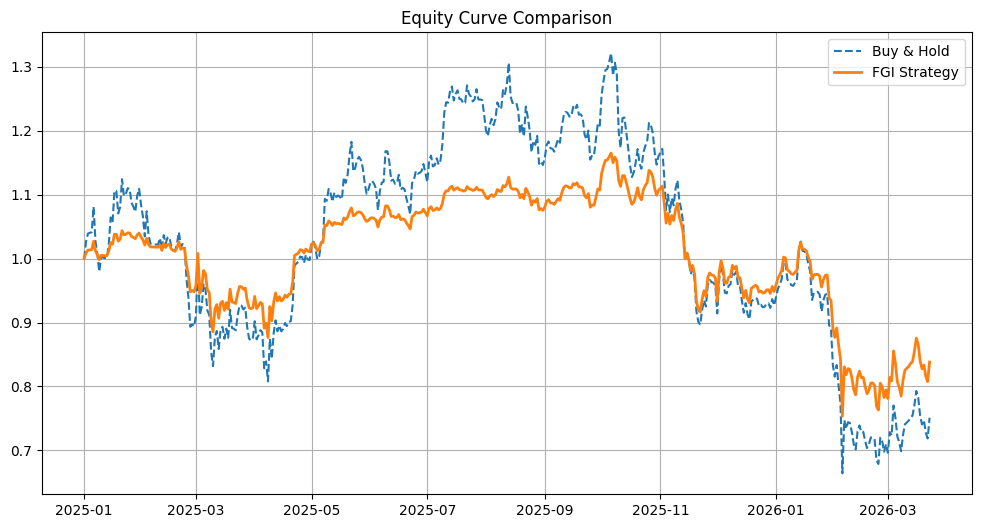

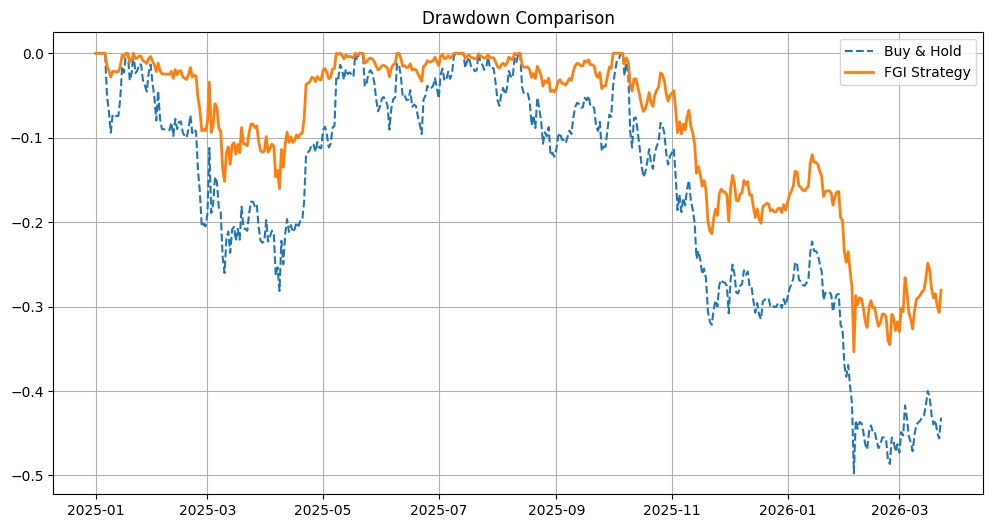

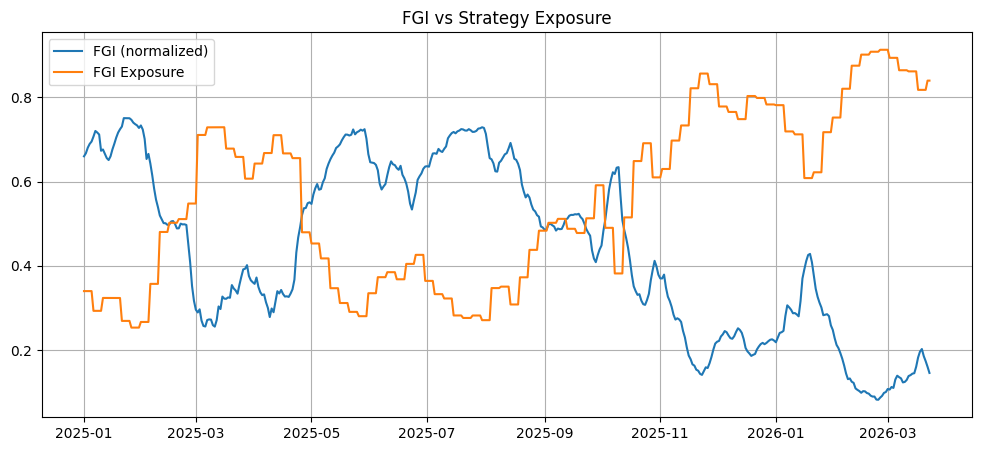

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# FGI-BASED STRATEGY (ANALOGOUS TO BUBBLE SCORE)
# ============================================================

df = df.copy()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

PRICE_COL = 'BCP'
FGI_COL = 'FGI'

fee = 0.001
REBALANCE_DAYS = 5

MAX_EXPOSURE = 1
ALPHA = 1   # same nonlinear mapping used before

# ------------------------------------------------------------
# DATA PREPARATION
# ------------------------------------------------------------

df[PRICE_COL] = df[PRICE_COL].astype(float)
df[FGI_COL] = df[FGI_COL].ffill().fillna(50)

df['ret'] = df[PRICE_COL].pct_change().fillna(0)

# ============================================================
# NORMALIZE FGI
# ============================================================

df['fgi_norm'] = (df[FGI_COL] / 100).clip(0, 1)

# ============================================================
# TARGET EXPOSURE (SAME FORMULA)
# ============================================================

df['target_position_fgi'] = MAX_EXPOSURE * (1 - df['fgi_norm']**ALPHA)

# ============================================================
# PERIODIC REBALANCING
# ============================================================

positions = []
current_position = df['target_position_fgi'].iloc[0]

for i in range(len(df)):

    if i % REBALANCE_DAYS == 0:
        current_position = df['target_position_fgi'].iloc[i]

    positions.append(current_position)

df['position_fgi'] = positions

# ============================================================
# RETURNS
# ============================================================

def apply_strategy(df, position_col, ret_col='ret', fee=0.001):
    out = df.copy()

    trade_col = f'trade_{position_col}'
    ret_strategy_col = f'ret_{position_col}'
    equity_col = f'equity_{position_col}'

    out[trade_col] = out[position_col].diff().abs().fillna(0)

    out[ret_strategy_col] = (
        out[position_col].shift(1).fillna(out[position_col]) * out[ret_col]
    )

    out[ret_strategy_col] -= out[trade_col] * fee

    out[equity_col] = (1 + out[ret_strategy_col]).cumprod()

    return out, ret_strategy_col, equity_col, trade_col


# Buy & Hold
df['position_bh'] = 1.0
df, ret_bh, equity_bh, trade_bh = apply_strategy(df, 'position_bh', fee=fee)

# 80% Buy & Hold (fair comparison)
df['position_80_bh'] = 0.80
df, ret_80_bh, equity_80_bh, trade_80_bh = apply_strategy(df, 'position_80_bh', fee=fee)

# FGI strategy
df, ret_fgi, equity_fgi, trade_fgi = apply_strategy(df, 'position_fgi', fee=fee)

# ============================================================
# METRICS
# ============================================================

def compute_drawdown(equity):
    peak = equity.cummax()
    return (equity - peak) / peak


def compute_metrics(df, ret_col, equity_col, trade_col, position_col, name):
    ret = df[ret_col]
    equity = df[equity_col]

    total_return = equity.iloc[-1] / equity.iloc[0] - 1
    ann_return = (1 + total_return) ** (365 / len(df)) - 1
    ann_vol = ret.std() * np.sqrt(365)
    sharpe = ann_return / ann_vol if ann_vol != 0 else np.nan

    dd = compute_drawdown(equity)
    max_dd = dd.min()
    calmar = ann_return / abs(max_dd) if max_dd != 0 else np.nan

    return {
        'Strategy': name,
        'Final Value': equity.iloc[-1],
        'Total Return': total_return,
        'Annual Return': ann_return,
        'Annual Volatility': ann_vol,
        'Sharpe Ratio': sharpe,
        'Max Drawdown': max_dd,
        'Calmar Ratio': calmar,
        'Average Exposure': df[position_col].mean(),
        'Turnover': df[trade_col].sum()
    }


metrics = pd.DataFrame([
    compute_metrics(df, ret_bh, equity_bh, trade_bh, 'position_bh', 'Buy & Hold'),
    compute_metrics(df, ret_80_bh, equity_80_bh, trade_80_bh, 'position_80_bh', '80% Buy & Hold'),
    compute_metrics(df, ret_fgi, equity_fgi, trade_fgi, 'position_fgi', 'FGI Strategy')
])

display(metrics)

# ============================================================
# DRAWDOWNS
# ============================================================

df['dd_bh'] = compute_drawdown(df[equity_bh])
df['dd_80_bh'] = compute_drawdown(df[equity_80_bh])
df['dd_fgi'] = compute_drawdown(df[equity_fgi])

# ============================================================
# PLOTS
# ============================================================

# Equity comparison
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df[equity_bh], label='Buy & Hold', linestyle='--')
#plt.plot(df['Date'], df[equity_80_bh], label='80% Buy & Hold')
plt.plot(df['Date'], df[equity_fgi], label='FGI Strategy', linewidth=2)
plt.title('Equity Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()

# Drawdown comparison
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['dd_bh'], label='Buy & Hold', linestyle='--')
#plt.plot(df['Date'], df['dd_80_bh'], label='80% Buy & Hold')
plt.plot(df['Date'], df['dd_fgi'], label='FGI Strategy', linewidth=2)
plt.title('Drawdown Comparison')
plt.legend()
plt.grid(True)
plt.show()

# FGI vs exposure
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['fgi_norm'], label='FGI (normalized)')
plt.plot(df['Date'], df['position_fgi'], label='FGI Exposure')
plt.title('FGI vs Strategy Exposure')
plt.legend()
plt.grid(True)
plt.show()

### Strategia LPPLS*FGI con fear exit

,Strategy,Final Value,Total Return,Annual Return,Annual Volatility,Sharpe Ratio,Max Drawdown,Calmar Ratio,Average Exposure,Turnover
0,Buy & Hold,0.751060,-0.248940,-0.208445,0.459956,-0.453184,-0.497388,-0.419078,1.000000,0.000000
1,80% Buy & Hold,0.812057,-0.187943,-0.156330,0.367965,-0.424850,-0.419264,-0.372868,0.800000,0.000000
2,LPPLS × FGI + Fear Exit,0.950811,-0.049189,-0.040350,0.178737,-0.225754,-0.220362,-0.183110,0.414977,4.693503


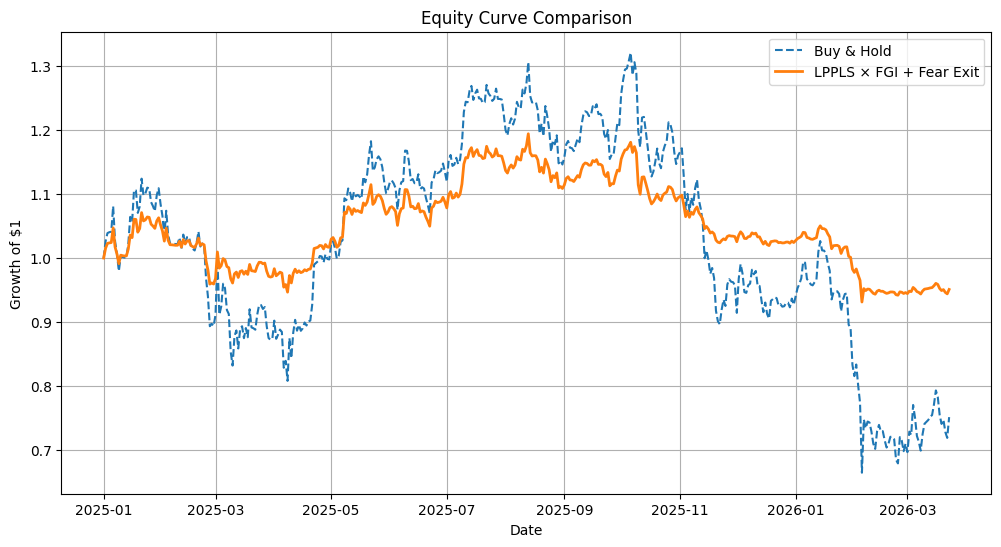

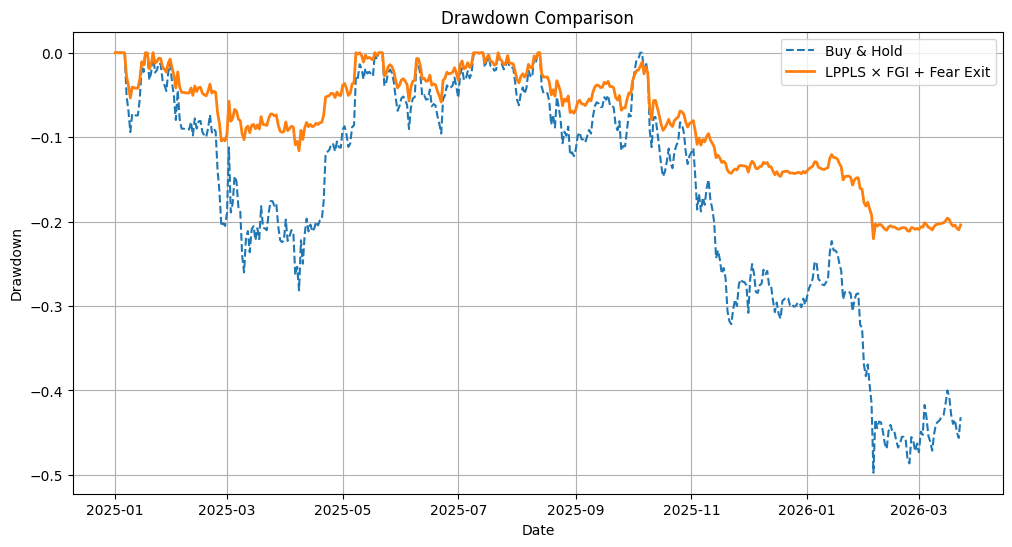

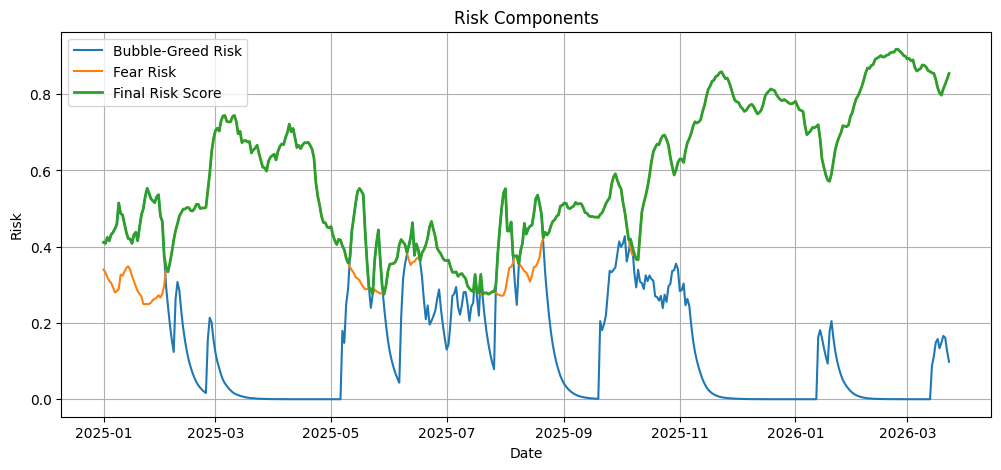

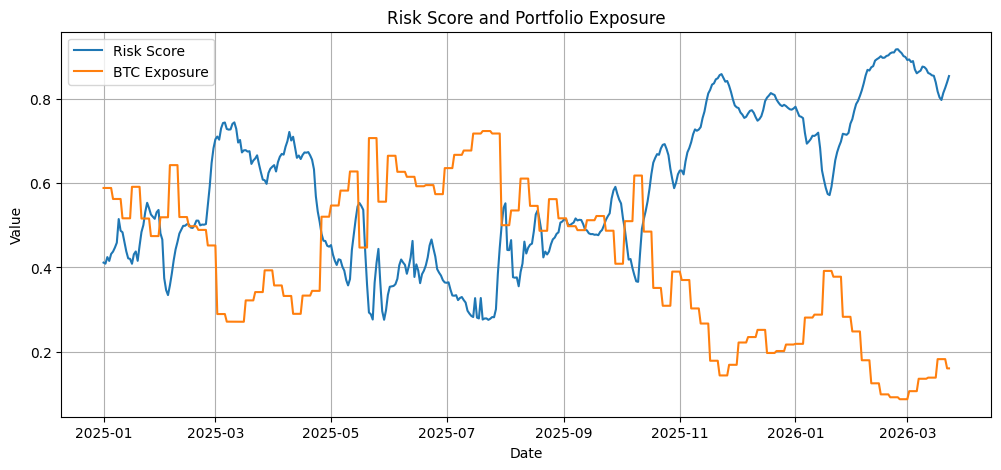

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# LPPLS + FGI STRATEGY WITH FEAR EXIT
# ============================================================

df = df.copy()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

PRICE_COL = 'BCP'
BUBBLE_COL = 'bubble_score'
FGI_COL = 'FGI'

fee = 0.001
REBALANCE_DAYS = 5
MAX_EXPOSURE = 1
ALPHA = 1

# ------------------------------------------------------------
# DATA PREPARATION
# ------------------------------------------------------------

df[PRICE_COL] = df[PRICE_COL].astype(float)
df[BUBBLE_COL] = df[BUBBLE_COL].ffill().fillna(0).clip(0, 1)
df[FGI_COL] = df[FGI_COL].ffill().fillna(50)

df['ret'] = df[PRICE_COL].pct_change().fillna(0)

# ------------------------------------------------------------
# SIGNALS
# ------------------------------------------------------------

df['lppls_score'] = df[BUBBLE_COL]
df['fgi_norm'] = (df[FGI_COL] / 100).clip(0, 1)

# Greed/bubble risk: high when both LPPLS and FGI are high
df['bubble_greed_risk'] = (df['lppls_score'] * df['fgi_norm'])**(0.5)

# Fear risk: high when FGI is low
df['fear_risk'] = 1 - df['fgi_norm']

# Final risk score: risk is high either in euphoric bubble or panic/fear
df['risk_score'] = np.maximum(df['bubble_greed_risk'], df['fear_risk']).clip(0, 1)

# ------------------------------------------------------------
# TARGET EXPOSURE
# ------------------------------------------------------------

df['target_position_risk'] = MAX_EXPOSURE * (1 - df['risk_score']**ALPHA)

# ------------------------------------------------------------
# PERIODIC REBALANCING
# ------------------------------------------------------------

positions = []
current_position = df['target_position_risk'].iloc[0]

for i in range(len(df)):
    if i % REBALANCE_DAYS == 0:
        current_position = df['target_position_risk'].iloc[i]
    positions.append(current_position)

df['position_risk'] = positions

# ------------------------------------------------------------
# APPLY STRATEGY
# ------------------------------------------------------------

def apply_strategy(df, position_col, ret_col='ret', fee=0.001):
    out = df.copy()

    trade_col = f'trade_{position_col}'
    ret_strategy_col = f'ret_{position_col}'
    equity_col = f'equity_{position_col}'

    out[trade_col] = out[position_col].diff().abs().fillna(0)

    out[ret_strategy_col] = (
        out[position_col].shift(1).fillna(out[position_col]) * out[ret_col]
    )

    out[ret_strategy_col] -= out[trade_col] * fee
    out[equity_col] = (1 + out[ret_strategy_col]).cumprod()

    return out, ret_strategy_col, equity_col, trade_col

# ------------------------------------------------------------
# BENCHMARKS
# ------------------------------------------------------------

df['position_bh'] = 1.0
df['position_80_bh'] = 0.80

df, ret_bh, equity_bh, trade_bh = apply_strategy(df, 'position_bh', fee=fee)
df, ret_80_bh, equity_80_bh, trade_80_bh = apply_strategy(df, 'position_80_bh', fee=fee)
df, ret_risk, equity_risk, trade_risk = apply_strategy(df, 'position_risk', fee=fee)

# ------------------------------------------------------------
# METRICS
# ------------------------------------------------------------

def compute_drawdown(equity):
    peak = equity.cummax()
    return (equity - peak) / peak


def compute_metrics(df, ret_col, equity_col, trade_col, position_col, name):
    ret = df[ret_col]
    equity = df[equity_col]

    total_return = equity.iloc[-1] / equity.iloc[0] - 1
    ann_return = (1 + total_return) ** (365 / len(df)) - 1
    ann_vol = ret.std() * np.sqrt(365)
    sharpe = ann_return / ann_vol if ann_vol != 0 else np.nan

    dd = compute_drawdown(equity)
    max_dd = dd.min()
    calmar = ann_return / abs(max_dd) if max_dd != 0 else np.nan

    return {
        'Strategy': name,
        'Final Value': equity.iloc[-1],
        'Total Return': total_return,
        'Annual Return': ann_return,
        'Annual Volatility': ann_vol,
        'Sharpe Ratio': sharpe,
        'Max Drawdown': max_dd,
        'Calmar Ratio': calmar,
        'Average Exposure': df[position_col].mean(),
        'Turnover': df[trade_col].sum()
    }


metrics = pd.DataFrame([
    compute_metrics(df, ret_bh, equity_bh, trade_bh, 'position_bh', 'Buy & Hold'),
    compute_metrics(df, ret_80_bh, equity_80_bh, trade_80_bh, 'position_80_bh', '80% Buy & Hold'),
    compute_metrics(df, ret_risk, equity_risk, trade_risk, 'position_risk', 'LPPLS × FGI + Fear Exit')
])

display(metrics)

# ------------------------------------------------------------
# DRAWDOWNS
# ------------------------------------------------------------

df['dd_bh'] = compute_drawdown(df[equity_bh])
df['dd_80_bh'] = compute_drawdown(df[equity_80_bh])
df['dd_risk'] = compute_drawdown(df[equity_risk])

# ------------------------------------------------------------
# PLOTS
# ------------------------------------------------------------

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df[equity_bh], label='Buy & Hold', linestyle='--')
#plt.plot(df['Date'], df[equity_80_bh], label='80% Buy & Hold')
plt.plot(df['Date'], df[equity_risk], label='LPPLS × FGI + Fear Exit', linewidth=2)
plt.title('Equity Curve Comparison')
plt.xlabel('Date')
plt.ylabel('Growth of $1')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['dd_bh'], label='Buy & Hold', linestyle='--')
#plt.plot(df['Date'], df['dd_80_bh'], label='80% Buy & Hold')
plt.plot(df['Date'], df['dd_risk'], label='LPPLS × FGI + Fear Exit', linewidth=2)
plt.title('Drawdown Comparison')
plt.xlabel('Date')
plt.ylabel('Drawdown')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['bubble_greed_risk'], label='Bubble-Greed Risk')
plt.plot(df['Date'], df['fear_risk'], label='Fear Risk')
plt.plot(df['Date'], df['risk_score'], label='Final Risk Score', linewidth=2)
plt.title('Risk Components')
plt.xlabel('Date')
plt.ylabel('Risk')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['risk_score'], label='Risk Score')
plt.plot(df['Date'], df['position_risk'], label='BTC Exposure')
plt.title('Risk Score and Portfolio Exposure')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

### Stesso con composizione additiva LBS e FGI

,Strategy,Final Value,Total Return,Annual Return,Annual Volatility,Sharpe Ratio,Max Drawdown,Calmar Ratio,Average Exposure,Turnover
0,Buy & Hold,0.751060,-0.248940,-0.208445,0.459956,-0.453184,-0.497388,-0.419078,1.000000,0.000000
1,80% Buy & Hold,0.812057,-0.187943,-0.156330,0.367965,-0.424850,-0.419264,-0.372868,0.800000,0.000000
2,LPPLS × FGI + Fear Exit,0.953395,-0.046605,-0.038221,0.173241,-0.220623,-0.216275,-0.176723,0.400492,4.378519


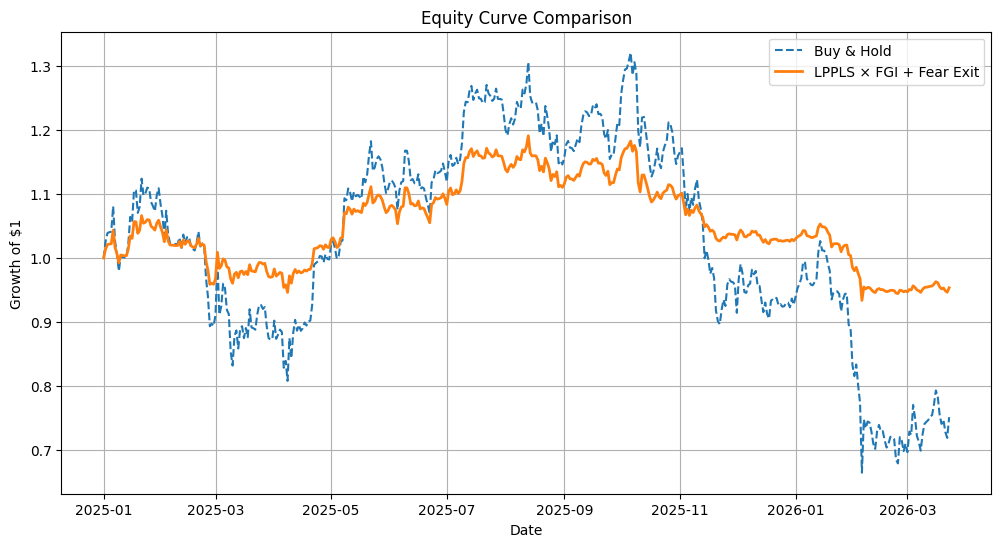

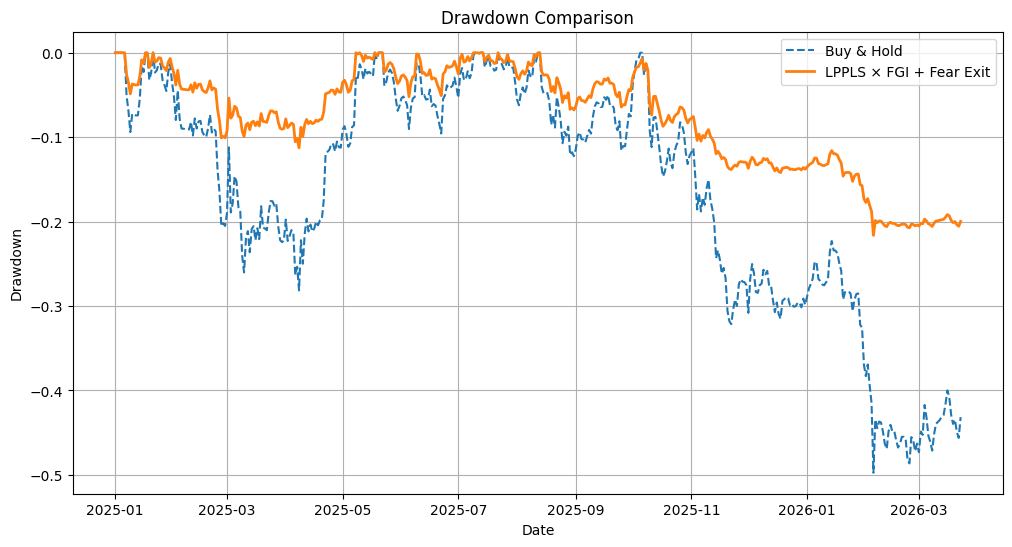

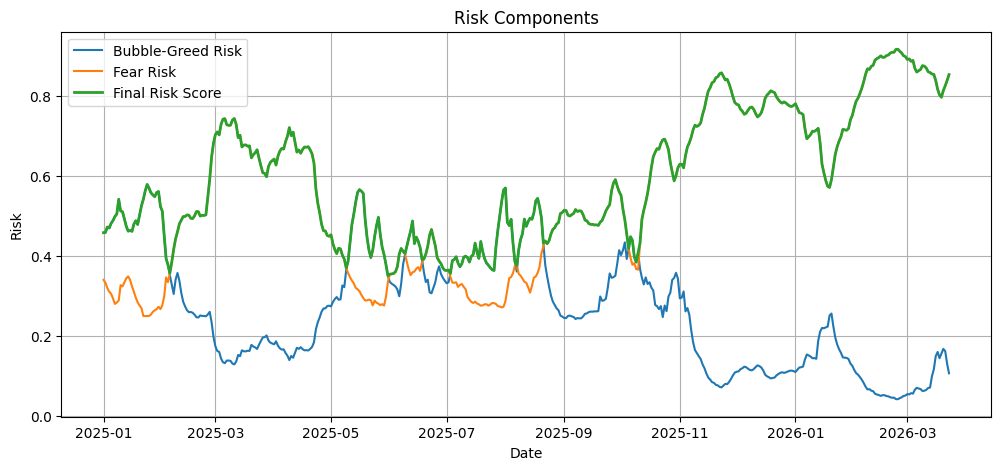

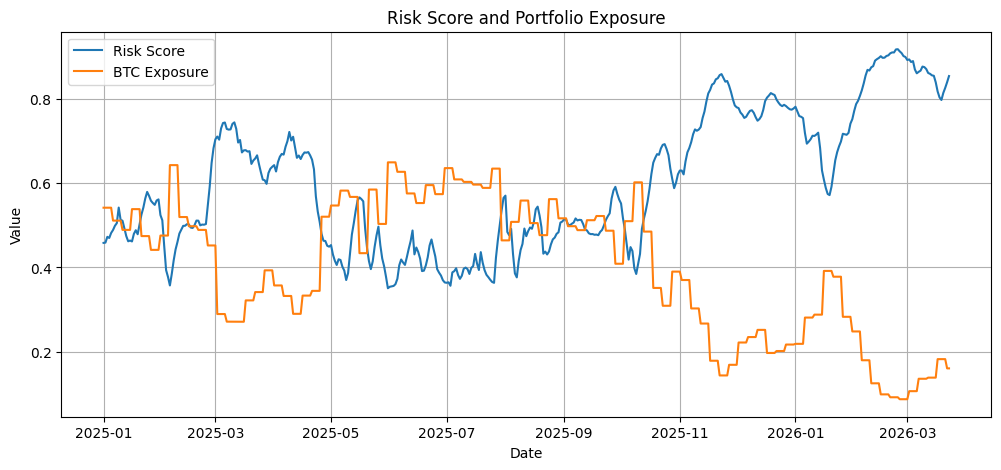

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# LPPLS + FGI STRATEGY WITH FEAR EXIT
# ============================================================

df = df.copy()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

PRICE_COL = 'BCP'
BUBBLE_COL = 'bubble_score'
FGI_COL = 'FGI'

fee = 0.001
REBALANCE_DAYS = 5
MAX_EXPOSURE = 1
ALPHA = 1

# ------------------------------------------------------------
# DATA PREPARATION
# ------------------------------------------------------------

df[PRICE_COL] = df[PRICE_COL].astype(float)
df[BUBBLE_COL] = df[BUBBLE_COL].ffill().fillna(0).clip(0, 1)
df[FGI_COL] = df[FGI_COL].ffill().fillna(50)

df['ret'] = df[PRICE_COL].pct_change().fillna(0)

# ------------------------------------------------------------
# SIGNALS
# ------------------------------------------------------------

df['lppls_score'] = df[BUBBLE_COL]
df['fgi_norm'] = (df[FGI_COL] / 100).clip(0, 1)

# Greed/bubble risk: high when both LPPLS and FGI are high
df['bubble_greed_risk'] = 0.5*df['lppls_score'] + 0.5*df['fgi_norm']

# Fear risk: high when FGI is low
df['fear_risk'] = 1 - df['fgi_norm']

# Final risk score: risk is high either in euphoric bubble or panic/fear
df['risk_score'] = np.maximum(df['bubble_greed_risk'], df['fear_risk']).clip(0, 1)

# ------------------------------------------------------------
# TARGET EXPOSURE
# ------------------------------------------------------------

df['target_position_risk'] = MAX_EXPOSURE * (1 - df['risk_score']**ALPHA)

# ------------------------------------------------------------
# PERIODIC REBALANCING
# ------------------------------------------------------------

positions = []
current_position = df['target_position_risk'].iloc[0]

for i in range(len(df)):
    if i % REBALANCE_DAYS == 0:
        current_position = df['target_position_risk'].iloc[i]
    positions.append(current_position)

df['position_risk'] = positions

# ------------------------------------------------------------
# APPLY STRATEGY
# ------------------------------------------------------------

def apply_strategy(df, position_col, ret_col='ret', fee=0.001):
    out = df.copy()

    trade_col = f'trade_{position_col}'
    ret_strategy_col = f'ret_{position_col}'
    equity_col = f'equity_{position_col}'

    out[trade_col] = out[position_col].diff().abs().fillna(0)

    out[ret_strategy_col] = (
        out[position_col].shift(1).fillna(out[position_col]) * out[ret_col]
    )

    out[ret_strategy_col] -= out[trade_col] * fee
    out[equity_col] = (1 + out[ret_strategy_col]).cumprod()

    return out, ret_strategy_col, equity_col, trade_col

# ------------------------------------------------------------
# BENCHMARKS
# ------------------------------------------------------------

df['position_bh'] = 1.0
df['position_80_bh'] = 0.80

df, ret_bh, equity_bh, trade_bh = apply_strategy(df, 'position_bh', fee=fee)
df, ret_80_bh, equity_80_bh, trade_80_bh = apply_strategy(df, 'position_80_bh', fee=fee)
df, ret_risk, equity_risk, trade_risk = apply_strategy(df, 'position_risk', fee=fee)

# ------------------------------------------------------------
# METRICS
# ------------------------------------------------------------

def compute_drawdown(equity):
    peak = equity.cummax()
    return (equity - peak) / peak


def compute_metrics(df, ret_col, equity_col, trade_col, position_col, name):
    ret = df[ret_col]
    equity = df[equity_col]

    total_return = equity.iloc[-1] / equity.iloc[0] - 1
    ann_return = (1 + total_return) ** (365 / len(df)) - 1
    ann_vol = ret.std() * np.sqrt(365)
    sharpe = ann_return / ann_vol if ann_vol != 0 else np.nan

    dd = compute_drawdown(equity)
    max_dd = dd.min()
    calmar = ann_return / abs(max_dd) if max_dd != 0 else np.nan

    return {
        'Strategy': name,
        'Final Value': equity.iloc[-1],
        'Total Return': total_return,
        'Annual Return': ann_return,
        'Annual Volatility': ann_vol,
        'Sharpe Ratio': sharpe,
        'Max Drawdown': max_dd,
        'Calmar Ratio': calmar,
        'Average Exposure': df[position_col].mean(),
        'Turnover': df[trade_col].sum()
    }


metrics = pd.DataFrame([
    compute_metrics(df, ret_bh, equity_bh, trade_bh, 'position_bh', 'Buy & Hold'),
    compute_metrics(df, ret_80_bh, equity_80_bh, trade_80_bh, 'position_80_bh', '80% Buy & Hold'),
    compute_metrics(df, ret_risk, equity_risk, trade_risk, 'position_risk', 'LPPLS × FGI + Fear Exit')
])

display(metrics)

# ------------------------------------------------------------
# DRAWDOWNS
# ------------------------------------------------------------

df['dd_bh'] = compute_drawdown(df[equity_bh])
df['dd_80_bh'] = compute_drawdown(df[equity_80_bh])
df['dd_risk'] = compute_drawdown(df[equity_risk])

# ------------------------------------------------------------
# PLOTS
# ------------------------------------------------------------

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df[equity_bh], label='Buy & Hold', linestyle='--')
#plt.plot(df['Date'], df[equity_80_bh], label='80% Buy & Hold')
plt.plot(df['Date'], df[equity_risk], label='LPPLS × FGI + Fear Exit', linewidth=2)
plt.title('Equity Curve Comparison')
plt.xlabel('Date')
plt.ylabel('Growth of $1')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['dd_bh'], label='Buy & Hold', linestyle='--')
#plt.plot(df['Date'], df['dd_80_bh'], label='80% Buy & Hold')
plt.plot(df['Date'], df['dd_risk'], label='LPPLS × FGI + Fear Exit', linewidth=2)
plt.title('Drawdown Comparison')
plt.xlabel('Date')
plt.ylabel('Drawdown')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['bubble_greed_risk'], label='Bubble-Greed Risk')
plt.plot(df['Date'], df['fear_risk'], label='Fear Risk')
plt.plot(df['Date'], df['risk_score'], label='Final Risk Score', linewidth=2)
plt.title('Risk Components')
plt.xlabel('Date')
plt.ylabel('Risk')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['risk_score'], label='Risk Score')
plt.plot(df['Date'], df['position_risk'], label='BTC Exposure')
plt.title('Risk Score and Portfolio Exposure')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()